# Input:

## import

In [1]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [2]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
import gym

## Data Installation:

In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/vcb_Training_Data.csv")
'''
data = data.set_index("Date")
'''
data.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
data.set_index("time", inplace=True)

training_data = data.loc[:, ~data.columns.isin(["target", "strength target", "regression target"])].copy()
target= data.loc[:, ["target"]].copy()

data.head()
display(training_data.shape, target.shape)

(3214, 108)

(3214, 1)

['hour', 'minute', 'minute_segment', 'monday_morning', 'friday_afternoon', 'pre_holiday_afternoon', 'post_holiday_morning', 'volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


Text(0, 0.5, 'Price')

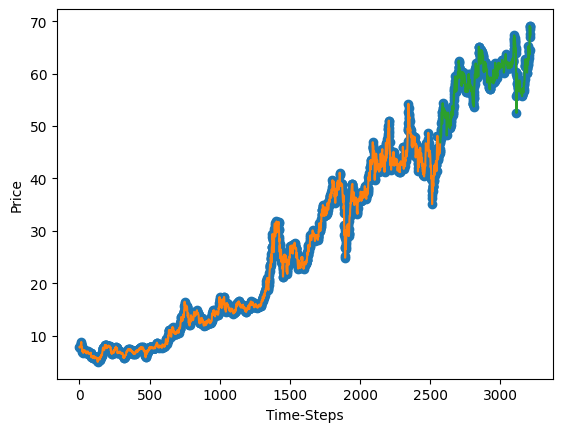

In [4]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

### GMM model import:

In [5]:
import joblib
from sklearn.mixture import GaussianMixture

package = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/gmm_model_with_threshold.pkl")

gmm_model = package["model"]
gmm_array = package["array"]

gmm_model, gmm_array

(GaussianMixture(n_components=4, random_state=42), 'log_return')

# M1 layers processing:

## Fold CV fucntion:

In [6]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

## Adding models:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_threshold.pkl", "logr_model_with_threshold.pkl", "rf_model_with_threshold.pkl", "xgb_model_with_threshold.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")

In [8]:
for key, infor in model_infor.items():
    print(f"{key}: {infor['model']}")

KNNs: KNeighborsClassifier(algorithm='kd_tree', leaf_size=16, n_jobs=-1,
                     n_neighbors=3, p=1)
LogR: LogisticRegression(C=1.8727005942368125, class_weight='balanced',
                   l1_ratio=0.9507143064099162, max_iter=1000, random_state=42,
                   solver='saga')
RF: RandomForestClassifier(class_weight='balanced', max_depth=3,
                       max_features=0.9729188669457949, min_samples_leaf=8,
                       min_samples_split=5, n_estimators=95, n_jobs=-1,
                       random_state=42)
XGB: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.18485445552552704, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=9.695846277645586, grow_policy=None, importance_type=None,
              interaction_con

## M1-models Processing:

### Sub-dataset preparation:

In [9]:
from sklearn.metrics import f1_score, accuracy_score, precision_score

sub_training_data = X.copy()
sub_testing_data = Valid_set.copy()

preds_train = []
preds_test = []
for name, infor in model_infor.items():
    model = infor["model"]
    
    # record in the train-set
    X_train_1 = X.loc[:, infor["feature set"]].copy()
    model.fit(X_train_1, y)
    
    y_proba = model.predict_proba(X_train_1)

    preds_train.append(model.predict_proba(X_train_1)[0, 1])
    
    '''
    y_pred = model.predict(X_train_1)
    '''
    y_pred = (y_proba[:, 1] > infor["threshold"]).astype(int)
    if len(np.unique(y_pred)) < 2:
        sub_training_data[f"{name}_proba_up"] = y_proba[:, 1]
        sub_training_data[f"{name}_proba_down"] = y_proba[:, 0]
    else:
        sub_training_data[f"{name}_proba_up"] = y_proba[:, 1]
        sub_training_data[f"{name}_proba_down"] = y_proba[:, 0]
        sub_training_data[f"{name}_prediction"] = y_pred
        #sub_training_data[f"{name}_valid"] = ( y_pred == y.to_numpy().T[0] ).astype(int)
    
    print()
    print( f"{name}_f1_score: {f1_score(y_true=y, y_pred=y_pred)}" )
    print( f"{name}_accuracny_score: {accuracy_score(y_true=y, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))
    
    # record in the test-set
    X_test_1 = Valid_set.loc[:, infor["feature set"]].copy()
    
    y_proba = model.predict_proba(X_test_1)
    
    preds_test.append(model.predict_proba(X_test_1)[0, 1])
    
    '''
    y_pred = model.predict(X_test_1)
    '''
    y_pred = (y_proba[:, 1] > infor["threshold"]).astype(int)

    if len(np.unique(y_pred)) < 2:
        sub_testing_data[f"{name}_proba_up"] = y_proba[:, 1]
        sub_testing_data[f"{name}_proba_down"] = y_proba[:, 0]
    else:
        sub_testing_data[f"{name}_proba_up"] = y_proba[:, 1]
        sub_testing_data[f"{name}_proba_down"] = y_proba[:, 0]
        sub_testing_data[f"{name}_prediction"] = y_pred

    print( f"{name}_f1_score: {f1_score(y_true=Valid_result, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))


KNNs_f1_score: 0.6994834396839866
KNNs_accuracny_score: 0.6153247763516142
(array([0, 1]), array([ 440, 2131]))
KNNs_f1_score: 0.5632040050062578
(array([0, 1]), array([107, 536]))

LogR_f1_score: 0.6178861788617886
LogR_accuracny_score: 0.4515752625437573
(array([0, 1]), array([  41, 2530]))
LogR_f1_score: 0.5805739514348786
(array([1]), array([643]))

RF_f1_score: 0.6258099352051836
RF_accuracny_score: 0.46091015169194866
(array([0, 1]), array([  27, 2544]))
RF_f1_score: 0.5749440715883669
(array([0, 1]), array([ 12, 631]))

XGB_f1_score: 0.6218172071830609
XGB_accuracny_score: 0.4511863088292493
(array([1]), array([2571]))
XGB_f1_score: 0.5805739514348786
(array([1]), array([643]))


In [10]:
print(preds_train)
print(preds_test)
print()

for preds, df in zip([preds_train, preds_test], [sub_training_data, sub_testing_data]):
    mean_pred = np.mean(preds)     # consensus probability
    std_pred  = np.std(preds)      # disagreement / uncertainty
    max_pred  = np.max(preds)      # strongest signal
    min_pred  = np.min(preds)      # weakest signal
    print([mean_pred, std_pred, max_pred, min_pred])
    '''
    for name, value in zip(["mean_pred", "std_pred", "max_pred", "min_pred"], [mean_pred, std_pred, max_pred, min_pred]):
        df[name] = [mean_pred]*len(df)
    '''

[0.6666666666666666, 0.5032701521167825, 0.4958160179053484, 1.0]
[0.3333333333333333, 0.5067878388385637, 0.5270434707916373, 1.0]

[0.6664382091721994, 0.20432771929489757, 1.0, 0.4958160179053484]
[0.5917911607408836, 0.24741298121041433, 1.0, 0.3333333333333333]


### Regimes add:

In [11]:
gmm_model.fit(sub_training_data[["log_return"]])
sub_training_data["regimes"] = gmm_model.predict(sub_training_data[["log_return"]])
sub_testing_data["regimes"] = gmm_model.predict(sub_testing_data[["log_return"]])

display(sub_training_data.head())
display(sub_testing_data.head())

,open,high,low,close,volume,vnindex,vn30,hnx,gold,oil,...,KNNs_prediction,LogR_proba_up,LogR_proba_down,LogR_prediction,RF_proba_up,RF_proba_down,RF_prediction,XGB_proba_up,XGB_proba_down,regimes
0,7.82,7.91,7.79,7.82,404510.0,465.17,533.60,77.81,1631.900024,118.709999,...,1,0.503270,0.496730,1,0.495816,0.504184,1,1.0,0.0,1
1,7.84,7.84,7.70,7.77,643880.0,465.65,534.89,78.57,1643.000000,118.160004,...,1,0.505208,0.494792,1,0.504977,0.495023,1,1.0,0.0,0
2,7.89,7.89,7.72,7.77,560280.0,472.87,542.78,79.55,1641.400024,119.120003,...,1,0.504532,0.495468,1,0.501135,0.498865,1,1.0,0.0,0
3,7.84,7.84,7.74,7.74,507420.0,470.21,538.10,78.74,1659.599976,119.919998,...,0,0.504104,0.495896,1,0.505042,0.494958,1,1.0,0.0,0
4,7.86,7.96,7.77,7.86,587740.0,473.77,541.20,79.86,1664.000000,119.830002,...,0,0.504754,0.495246,1,0.495816,0.504184,1,1.0,0.0,1


,open,high,low,close,volume,vnindex,vn30,hnx,gold,oil,...,KNNs_proba_down,KNNs_prediction,LogR_proba_up,LogR_proba_down,RF_proba_up,RF_proba_down,RF_prediction,XGB_proba_up,XGB_proba_down,regimes
2571,46.95,46.95,46.33,46.89,838779.0,1046.35,1050.15,213.06,1852.800049,77.839996,...,0.666667,1,0.506788,0.493212,0.527043,0.472957,1,1.0,0.0,1
2572,46.89,47.57,46.72,47.57,1080011.0,1055.82,1061.90,213.11,1834.800049,78.690002,...,0.333333,1,0.508741,0.491259,0.467870,0.532130,1,1.0,0.0,1
2573,47.57,48.03,47.52,47.57,1127163.0,1051.44,1057.40,210.65,1864.199951,78.570000,...,0.333333,1,0.509122,0.490878,0.495816,0.504184,1,1.0,0.0,1
2574,48.59,49.22,48.03,49.22,1668531.0,1054.21,1061.14,209.67,1872.699951,79.650002,...,0.666667,1,0.513504,0.486496,0.463664,0.536336,1,1.0,0.0,1
2575,48.82,50.92,48.82,49.44,2114849.0,1053.35,1060.53,210.63,1871.599976,80.099998,...,1.000000,0,0.517116,0.482884,0.458281,0.541719,1,1.0,0.0,1


### The collaboration per regimes:

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_regimes_separately.pkl", "logr_model_with_regimes_separately.pkl", "rf_model_with_regimes_separately.pkl", "xgb_model_with_regimes_separately.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor_collab = {}

for name, path in zip(model_names, model_paths):
    model_infor_collab[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")
    
for key, infor in model_infor_collab.items():
    print(f"{key}: {infor}")

KNNs: {'Regime 0': KNeighborsClassifier(algorithm='ball_tree', leaf_size=12, n_jobs=-1, p=1,
                     weights='distance'), 'Regime 1': KNeighborsClassifier(algorithm='ball_tree', leaf_size=12, n_jobs=-1,
                     n_neighbors=1, p=1), 'Regime 2': KNeighborsClassifier(algorithm='brute', leaf_size=1, n_jobs=-1, n_neighbors=1,
                     p=1, weights='distance'), 'Regime 3': KNeighborsClassifier(algorithm='brute', leaf_size=29, n_jobs=-1, n_neighbors=48,
                     p=1), 'feature set': ['low', 'volume', 'weekday', 'hour', 'minute_segment', 'friday_afternoon', 'pre_holiday_afternoon', 'return', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_dcl', 'volatility_dch', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_sma_slow', 'trend_ema

In [13]:
from sklearn.metrics import f1_score, classification_report

for subdata, subtarget in zip([sub_training_data, sub_testing_data], [y, Valid_result]):
    labels_train = sub_training_data.regimes
    labels_test = subdata.regimes

    the_collab_pred = {}
    for i in np.unique(labels_train):
        the_collab_pred[f"Regime {i}"] = {}
        the_collab_pred[f"Regime {i} Score"] = {}

    for name, infor in model_infor_collab.items():
        X_train_aug = sub_training_data.loc[:, infor["feature set"]].copy()
        X_test_aug = subdata.loc[:, infor["feature set"]].copy()
        y_train = y.copy()
        y_test = subtarget.copy()
        
        # Train classifier
        the_final_pred = np.zeros(len(y_test))
        for i in np.unique(labels_test):
            clf = infor[f"Regime {i}"]
            clf.fit(X_train_aug.loc[ labels_train == i, :], y_train[labels_train == i])
            y_pred = clf.predict(X_test_aug.loc[ labels_test == i, :])
            the_final_pred[labels_test == i] = y_pred
            
            the_collab_pred[f"Regime {i}"][f"{name}"] = y_pred
            the_collab_pred[f"Regime {i} Score"][f"{name}"] = f1_score(y_true=y_test[labels_test == i], y_pred=y_pred)

        score = f1_score(y_test, the_final_pred)
        print( f"{name}: F1-{score}")


    print()
    the_final_pred = np.zeros(len(y_test))
    for i in np.unique(labels_train):
        
        indx = list(the_collab_pred[f"Regime {i} Score"].keys())[(np.argmax(list(the_collab_pred[f"Regime {i} Score"].values())))]
        
        condition = True
        l = the_collab_pred[f"Regime {i} Score"].copy()
        while condition:
            indx = list(l.keys())[(np.argmax(list(l.values())))]
            if len(np.unique(the_collab_pred[f"Regime {i}"][ indx ])) >= 2:
                condition = False
            l.pop(indx)
        
        the_final_pred[labels_test == i] = the_collab_pred[f"Regime {i}"][ indx ]
        
        print(f"{indx}: {f1_score(y_true=y_test[labels_test == i], y_pred=the_final_pred[labels_test == i])}")
        print(f"-- Test: {np.unique(y_test[labels_test == i], return_counts=True)}")
        print(f"-- Prediction: {np.unique(the_final_pred[labels_test == i], return_counts=True)}")
        
    print(f"\nF1-{f1_score(y_test, the_final_pred)}")
    print(f"-- Test: {np.unique(y_test, return_counts=True)}")
    print(f"-- Prediction: {np.unique(the_final_pred, return_counts=True)}")
    print(f"{classification_report(y_test, the_final_pred)}")

    subdata["collab_prediction"] = the_final_pred

KNNs: F1-0.9784537389100126
LogR: F1-0.606425702811245
RF: F1-0.6025336500395883
XGB: F1-0.6082289803220036

KNNs: 1.0
-- Test: (array([0., 1.]), array([485, 423]))
-- Prediction: (array([0., 1.]), array([485, 423]))
KNNs: 1.0
-- Test: (array([0., 1.]), array([735, 556]))
-- Prediction: (array([0., 1.]), array([735, 556]))
KNNs: 1.0
-- Test: (array([0., 1.]), array([141, 102]))
-- Prediction: (array([0., 1.]), array([141, 102]))
RF: 0.8625
-- Test: (array([0., 1.]), array([50, 79]))
-- Prediction: (array([0., 1.]), array([48, 81]))

F1-0.9905254091300603
-- Test: (array([0., 1.]), array([1411, 1160]))
-- Prediction: (array([0., 1.]), array([1409, 1162]))
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1411
         1.0       0.99      0.99      0.99      1160

    accuracy                           0.99      2571
   macro avg       0.99      0.99      0.99      2571
weighted avg       0.99      0.99      0.99      2571

KNNs: F1-0

### The Meta-Label

In [14]:
'''
for target, subdata in zip([y, Valid_result], [sub_training_data, sub_testing_data]):
    y_train = target.to_numpy().copy().T[0]
    y_pred = subdata['collab_prediction']

    future_returns = np.array([])
    for i, price_change in zip(y_pred[:-1], subdata["return"][1:]):
        future_returns = np.append(future_returns, reward_logit(action=i, price_change=price_change, training=True))

    future_returns = np.append(future_returns, 0)
    meta_labels = ((y_pred == y_train) & (future_returns > 0)).astype(int)

    display(np.unique(meta_labels, return_counts=True), len(meta_labels), len(subdata))
'''

'\nfor target, subdata in zip([y, Valid_result], [sub_training_data, sub_testing_data]):\n    y_train = target.to_numpy().copy().T[0]\n    y_pred = subdata[\'collab_prediction\']\n\n    future_returns = np.array([])\n    for i, price_change in zip(y_pred[:-1], subdata["return"][1:]):\n        future_returns = np.append(future_returns, reward_logit(action=i, price_change=price_change, training=True))\n\n    future_returns = np.append(future_returns, 0)\n    meta_labels = ((y_pred == y_train) & (future_returns > 0)).astype(int)\n\n    display(np.unique(meta_labels, return_counts=True), len(meta_labels), len(subdata))\n'

## dataframe set-up with the m1 layers:

In [15]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

def voting_method(data):
    score_array = []
    X_meta = []
    for name, infor in model_infor.items():
        check = 0
        for i in data.columns:
            if f"{name}_prediction" in i:
                check += 1
        if check < 1:
            continue
        
        '''
        y_pred= sub_training_data[f"{name}_prediction"]
        score = f1_score(y_pred=y_pred, y_true= y) 
        '''
        
        cv = purged_kfold_split(X.copy())
        score = cross_val_score(estimator=infor["model"], X=X.loc[:, infor["feature set"]].copy(), y=y.copy(), cv=cv, scoring="f1", n_jobs=-1).mean()
                
        score_array.append( score )
        
        X_meta.append(data[f"{name}_prediction"].tolist())
        print(f"{name}: {score_array[-1]}")

    # Weighted predictions (element-wise multiplication)
    score_array = np.array(score_array)
    #normalized_weights = score_array / score_array.sum()
    normalized_weights = score_array

    X_weighted = np.array(X_meta) * normalized_weights.reshape(len(score_array),1)
    
    # Same preds array as above
    weighted_votes = np.dot(X_weighted.T, normalized_weights)  # shape: (n_samples,)
    threshold = normalized_weights.sum() / 2
    final_preds = (weighted_votes >= threshold).astype(int)
    
    return final_preds

signals = []
record_1 = []
record_2 = []

def clustering_signal(target_signal: int, final_preds: np.array, data: pd.DataFrame = None): # just keep signal {1} or {0} for the input of the M2-layer

    zeros_array = np.zeros(len(final_preds))
    indexes = np.where(final_preds == target_signal)

    zeros_array[indexes] = 1
    
    if data is None:
        return zeros_array
    else:
        return data.iloc[indexes]

## M1-models Validation:

In [16]:
train_preds = voting_method(data=sub_training_data.copy())
test_preds = voting_method(data=sub_testing_data.copy())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_rati

LogR: 0.6213595158808086


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

RF: 0.45371227721326557
KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

RF: 0.45371227721326557


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [17]:
y_test, y_train = Valid_result.copy(), y.copy()
for i in [train_preds, test_preds, y_test, y_train]:
    i[i == 0] = -1

print(f"Train Count: {np.unique(train_preds, return_counts=True)}")
print(f"Test  Count: {np.unique(test_preds, return_counts=True)}")
print()
print(f"Train F1: {f1_score(y_pred=train_preds, y_true=y_train)}")
print(f"Test F1: {f1_score(y_pred=test_preds, y_true=y_test)}")
print()
train_returns = sub_training_data.iloc[np.where(train_preds == 1)]['return'].sum()
train_total_returns = sub_training_data.iloc[ np.where(sub_training_data['return'] > 0) ]['return'].sum()
test_returns = sub_testing_data.iloc[np.where(test_preds == 1)]['return'].sum()
test_total_returns = sub_testing_data.iloc[ np.where(sub_testing_data['return'] > 0) ]['return'].sum()

print(f"Train Return: {train_returns}")
print(f"Test Return: {test_returns}")
print()
print(f"Train Return Rate: {train_returns / train_total_returns}")
print(f"Test Return Rate: {test_returns / test_total_returns}")

Train Count: (array([-1,  1]), array([ 487, 2084]))
Test  Count: (array([-1]), array([643]))

Train F1: 0.6972872996300863
Test F1: 0.0

Train Return: -15.439999999999955
Test Return: 0.0

Train Return Rate: -0.038222552296076136
Test Return Rate: 0.0


In [18]:
final_preds = train_preds.copy()
clustering_signal(target_signal=-1, final_preds=final_preds)

array([0., 0., 0., ..., 1., 0., 1.])

# Data Preprocessing:

## Feature Scaling Functions:

In [19]:
# ---------------------------
# Feature Scaling Functions:
# ---------------------------

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()

## DataSet:

In [20]:
def dataset_preparation(sub_training_data, sub_testing_data, extended_feature: bool, feature_selection: list = False):
    if extended_feature:
        df1 = sub_training_data.copy()
        df2 = sub_testing_data.copy()
        '''
        arr = pd.concat([df1, y], axis=1).corrwith(pd.concat([df1, y], axis=1)['target']) > 0
        l= []
        for indx, value in arr.items():
            if (value == True or indx in ['return', 'close']) and indx != 'target':
                l.append(indx)
        df1 = df1.loc[:, l]
        df2 = df2.loc[:, l]
        '''

        if isinstance(feature_selection, list):
            if 'return' not in feature_selection:
                feature_selection.append('return')
            if 'close' not in feature_selection:
                feature_selection.append('close')
            
            col = list(X.columns)
            for i in feature_selection:
                col.remove(i)
            df1 = df1.loc[:, ~df1.columns.isin(col)]
            df2 = df2.loc[:, ~df2.columns.isin(col)]
        
    else:
        l = X.columns.tolist().copy()
        l.remove('return')
        l.remove('close')
        df1 = sub_training_data.loc[:, ~sub_training_data.columns.isin(l)]
        df2 = sub_testing_data.loc[:, ~sub_testing_data.columns.isin(l)]


    df1['final_preds'] = voting_method(data=df1.copy())
    df2['final_preds'] = voting_method(data=df2.copy())

    scale_method = scale_standard
    #scale_method = scale_minmax

    scale_1 = scale_method(df1)
    scale_2 = scale_method(df2)

    for j in scale_1.columns:
        if j != 'return' and j != 'close':
            df1[j] = scale_1[j]
    for j in scale_2.columns:
        if j != 'return' and j != 'close':
            df2[j] = scale_2[j]
            
    #------------------------------------------------------
    # GMM model:
    #------------------------------------------------------
    gmm_model.fit(sub_training_data[['log_return']])
    for df, subdata in zip( [df1, df2], [sub_training_data, sub_testing_data] ):
        df["regimes"] = gmm_model.predict(subdata[['log_return']])
    
    return df1, df2

In [21]:
df1, df2 = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=False)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/F

LogR: 0.6213595158808086
RF: 0.45371227721326557
KNNs: 0.4512464279130463


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_12203/2131272332.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['final_preds'] = voting_method(data=df1.copy())
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel

RF: 0.45371227721326557


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_12203/2131272332.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['final_preds'] = voting_method(data=df2.copy())
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_12203/2131272332.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[j] = scale_1[j]
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_12203/2131272332.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [74]:
df1.loc[ df1['return'] > 0 , ['return']].sum()

return    403.95
dtype: float64

In [75]:
display(df1), display(df2)

,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,regimes,collab_prediction
0,7.82,-0.811073,0.00,-0.035769,1.149375,-1.452408,0.517340,-0.050688,-0.038947,0.082699,...,0.081218,0.886388,1.919126,1.954113,1.609774,1.752463,0.313919,0.315771,1,0.0
1,7.77,-0.523942,-0.07,-0.522450,1.140409,-1.456174,0.869181,-0.067306,0.103335,0.106168,...,0.086416,0.163493,2.070926,1.969968,1.427866,1.746246,-0.037194,-0.770908,0,0.0
2,7.77,-0.624223,-0.12,-0.867425,1.140409,-1.462168,0.845274,-0.075603,0.023961,0.100986,...,0.129950,-0.618722,2.339311,2.293814,1.899041,1.855028,0.719748,-0.194754,0,0.0
3,7.74,-0.687630,-0.10,-0.732370,1.130181,-1.456952,0.902658,-0.089013,-0.027570,0.077618,...,0.089393,-0.452167,2.321728,1.789657,1.890100,1.939894,0.562335,-1.812377,0,0.0
4,7.86,-0.591284,0.00,-0.035769,1.107686,-1.461676,0.654668,-0.070612,-0.002589,0.079595,...,-0.072364,-0.368087,2.276525,1.312614,1.749310,1.973797,0.226881,0.865139,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566,44.80,-0.025871,-0.62,-0.781602,0.683547,1.762018,-2.086752,-0.271958,-6.321794,3.646798,...,1.015743,0.227233,-0.135869,1.750542,0.086960,0.062850,0.069316,2.498254,0,0.0
2567,45.31,0.112117,-0.23,-0.310527,0.648071,1.771878,-2.512371,-1.072831,-5.284256,2.360007,...,0.317356,0.594583,-0.132323,1.411431,0.152798,0.086716,0.160825,2.045578,0,0.0
2568,45.71,0.189181,-0.90,-1.093819,0.616692,1.782808,-2.888753,-0.806295,-1.405707,1.760463,...,-0.361016,0.615724,-0.090000,1.243637,0.434278,0.173767,0.576712,0.717857,0,0.0
2569,45.31,0.518027,-1.64,-1.965167,0.573452,1.794337,-3.044150,-0.651127,-0.767808,1.883305,...,-0.655491,0.860970,0.010927,1.265809,0.407807,0.237017,0.420049,-0.679047,3,1.0


,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,regimes,collab_prediction
2571,46.89,-0.483496,-0.06,-0.056472,0.472438,-1.453309,-1.950362,-0.055892,-0.182794,1.445389,...,-0.468066,-0.259160,0.383926,1.991951,0.183410,0.116279,0.171879,-0.036458,1,1.0
2572,47.57,-0.398209,0.68,1.190340,0.481908,-1.430596,-1.670676,-0.005530,0.257766,1.750062,...,-0.357454,-0.553822,0.535912,1.971739,0.387692,0.194424,0.439014,-4.390517,1,1.0
2573,47.57,-0.381538,0.00,0.045233,0.497027,-1.401350,-1.671473,0.020334,0.471034,1.854865,...,-0.243965,-0.408765,0.636987,1.827167,0.562309,0.301289,0.608312,-1.425895,1,1.0
2574,49.22,-0.190138,0.63,1.069802,0.484342,-1.370828,-1.219141,-0.020811,0.832511,1.382581,...,-0.321436,-1.880338,0.712309,1.646556,1.125970,0.529941,1.326192,-1.452459,1,1.0
2575,49.44,-0.032343,0.62,1.048920,0.507699,-1.325646,-1.129437,-0.051416,-1.413048,0.360018,...,-0.579105,-1.965956,0.878501,1.731249,1.126704,0.713050,1.057731,0.252262,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,69.00,2.330975,-0.50,-0.529015,-2.957888,4.622380,-0.312581,0.760550,0.040527,-0.203958,...,0.325985,0.223076,0.871357,2.152231,2.693927,1.920903,2.210686,-0.887782,0,1.0
3210,68.60,4.415748,-0.60,-0.647367,-3.042171,4.384103,-0.481328,1.323409,-0.004391,-0.144095,...,0.389753,-0.283794,1.193600,2.529372,2.907120,2.278014,2.083401,-0.036458,0,1.0
3211,67.00,4.246328,-1.80,-2.063278,-3.222185,3.986151,-0.685906,0.694971,0.278465,-0.108788,...,0.577305,1.501359,1.393738,2.523118,2.438041,2.444565,0.960132,1.070829,0,1.0
3212,68.90,2.381426,1.40,1.677934,-3.421207,3.601175,-0.399380,6.383122,-0.414806,-0.226422,...,0.576054,1.185610,1.424784,2.091647,2.025487,2.473024,0.146143,0.448420,1,1.0


(None, None)

# PPO Set-up:

In [24]:
#device = torch.device("mps" if torch.mps.is_available() else "cpu")
device = torch.device("cpu")
print(device)

cpu


## Environment set-up:

In [25]:
def reward_logit(training, action, price_change, based_signal):

    if training:
        
        reward = 0.0
        realized_return = price_change
        # Only relevant if base model suggests a trade
        if based_signal == 1:
            if action == 1:  # Agent executes
                reward = realized_return   # profit/loss as reward
            else:  # Agent ignores
                reward = 0.0               # neutral
        else:
            # If base model has no trade but agent executes, small penalty
            if action == 1:
                reward = realized_return  # discourage acting outside base signal
            else:
                reward = 0.0

        '''        
        pnl = price_change
        reward = 0
        if action == 1 and pnl <= 0:   # false positive trade
            reward -= 0.5              # penalty (tune λ)
        reward *= price_change
        '''

        '''
        if action == 1:  # BUY
            if price_change > 0:
                reward = 1 #- trading_cost     # profit minus cost
            else:
                reward = - 1 #- trading_cost     # negative return (loss + cost)
        elif action == 0:  # HOLD
            if price_change <= 0:
                reward = 1          # reward for avoiding a loss
            else:
                reward = -1             # penalty for missing profit
        else:  # Neutral case
            reward = 0.0
        '''
        '''
        # PnL framework:
        if action == 1:
            reward = 1.0            # correct buy
            #reward -= 0.05          # trading cost
        elif action == 0:
            reward = -0.5
        else:
            reward = 0.0            # price_change == 0
        reward *= price_change
        '''
        
    else:
        # Calculate the reward based on the action
        '''
        if action == 1:
            if price_change > 0:
                reward = 1.0            # correct buy
            elif price_change <= 0:
                reward = -1.0           # bad buy
            reward -= 0.05  # trading cost
        elif action == 0:
            if price_change <= 0:
                reward = 0            # good avoid
            elif price_change > 0:
                reward = 0           # missed opportunity
        else:
            reward = 0.0            # price_change == 0
        '''
        if action == 1:
            reward = 1.0            # correct buy
            reward -= 0.05  # trading cost
        elif action == 0:
            reward = -1            # price_change == 0
        else:
            reward = 0.0            # price_change == 0
        reward *= price_change
        
    return reward

class TradingEnv(gym.Env):
    def __init__(self, data, device=device, training=True):
        super(TradingEnv, self).__init__()
        self.data = data
        self.device = torch.device(device)
        self.training = training

        self.current_step = 0
        self.position = 0
        self.initial_balance = 0
        self.done = False

        # Define action space: Buy (1), Sell (0)
        self.action_space = gym.spaces.Discrete(2)

        # Define observation space: using normalized price and technical indicators
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.data.columns)-1,),
            dtype=np.float32
        )

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.total_profit = 0
        self.position = 0
        self.entry_price = 0
        self.done = False

        return self._get_observation()

    def _get_observation(self):
        '''
        obs_list = [
            self.data[col].iloc[self.current_step]
            for col in self.data.columns
            if col not in ("return", "close")
        ]
        '''
        obs_list = [
            self.data[col].iloc[self.current_step]
            for col in self.data.columns
            if col not in ("base_signal")
        ]
        
        obs = torch.tensor(obs_list, dtype=torch.float32, device=self.device)
        return obs

    def step(self, action):
        self.current_step += 1
        reward = 0
        rate_of_return = 0

        if self.current_step >= len(self.data) - 2:
            self.done = True

        price_change = self.data['return'].iloc[self.current_step + 1]

        reward_value = reward_logit(action=action, price_change=price_change, training=self.training)
        reward = torch.tensor(reward_value, dtype=torch.float32, device=self.device)

        obs = self._get_observation()

        actual_movement = int(price_change > 0)
        actual_returns = price_change if price_change > 0 else 0

        info = {
            "actual_movement": torch.tensor(actual_movement, device=self.device),
            "Rate of Return": torch.tensor(rate_of_return, dtype=torch.float32, device=self.device),
            "Actual Return": torch.tensor(actual_returns, dtype=torch.float32, device=self.device),
        }
        
        return obs, reward, self.done, info

### parrallel tructure:

In [26]:
class TradingEnv_parallel(gym.Env):
    def __init__(self, data, training=True):
        super(TradingEnv_parallel, self).__init__()
        self.data = data.reset_index(drop=True)
        self.training = training

        # Define action space: Buy (1), Hold (0)
        self.action_space = gym.spaces.Discrete(2)

        # Define observation space: 5 indicators
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.data.columns),),
            dtype=np.float32
        )

        self.current_step = 0
        self.initial_balance = 0.0
        self.balance = 0.0
        self.total_profit = 0.0
        self.position = 0
        self.entry_price = 0.0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.total_profit = 0.0
        self.position = 0
        self.entry_price = 0.0
        self.current_step = 0

        obs = self._get_observation()
        info = {}
        return obs, info

    def _get_observation(self):
        '''
        obs_list = [
            self.data[col].iloc[self.current_step]
            for col in self.data.columns
            if col not in ("return", "close")
        ]
        '''
        obs_list = [
            self.data[col].iloc[self.current_step]
            for col in self.data.columns
        ]
        obs = np.array(obs_list, dtype=np.float32)
        return obs

    def step(self, action):
        self.current_step += 1
        terminated = False
        truncated = False

        if self.current_step >= len(self.data) - 2:
            truncated = True

        price_change = self.data['return'].iloc[self.current_step + 1]
        based_signal = self.data['collab_prediction'].iloc[self.current_step]
        reward = reward_logit(action=action, price_change=price_change, training=self.training, based_signal=based_signal)

        obs = self._get_observation()

        actual_movement = int(price_change > 0)
        actual_returns = price_change if price_change > 0 else 0

        info = {
            "actual_movement": actual_movement,
            "Rate of Return": 0.0,
            "Actual Return": actual_returns,
        }

        return obs, float(reward), terminated, truncated, info
    
# VecEnv factory helper for parallel use
def make_env(data, seed=0, rank=0):
    def _init():
        env = TradingEnv_parallel(data=data.copy(), training=True)
        env.reset(seed=seed + rank)
        return env
    return _init

## Memmory Set-up:

In [27]:
# Memory to store transitions
class Memory:
    def __init__(self, device=device):
        self.device = torch.device(device)
        self.states, self.actions, self.logprobs, self.rewards, self.dones, self.values = [], [], [], [], [], []
    
    def add(self, state, action, logprob, reward, done):
        # Ensure all tensors are moved to the target device
        self.states.append(torch.as_tensor(state, device=self.device, dtype=torch.float32))
        self.actions.append(torch.as_tensor(action, device=self.device))
        self.logprobs.append(torch.as_tensor(logprob, device=self.device, dtype=torch.float32))
        self.rewards.append(torch.as_tensor(reward, device=self.device, dtype=torch.float32))
        self.dones.append(torch.as_tensor(done, device=self.device, dtype=torch.bool))
    
    def clear(self):
        self.__init__(device=self.device)


### RND

In [28]:
class Memory_RND:
    def __init__(self):
        self.clear()

    def add(self, state, action, logprob, reward, done):
        self.states.append(state)
        self.actions.append(action)
        self.logprobs.append(logprob)
        self.rewards.append(reward)
        self.dones.append(done)

    def clear(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.dones = []
        self.next_state = None

## Agent function:

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, sigma_init=0.05):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Learnable parameters
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.full((out_features, in_features), sigma_init))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.full((out_features,), sigma_init))

        # Buffers for noise
        self.register_buffer("weight_eps", torch.empty(out_features, in_features))
        self.register_buffer("bias_eps", torch.empty(out_features))

        self.reset_parameters()

    def reset_parameters(self):
        mu_range = 1.0 / self.in_features ** 0.5
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.bias_mu.data.uniform_(-mu_range, mu_range)

    def sample_noise(self):
        self.weight_eps.normal_()
        self.bias_eps.normal_()

    def forward(self, x):
        if self.training:
            self.sample_noise()  # sample fresh noise each forward
            weight = self.weight_mu + self.weight_sigma * self.weight_eps
            bias = self.bias_mu + self.bias_sigma * self.bias_eps
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(x, weight, bias)

In [30]:
class ActorCriticLSTM(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64, lstm_hidden=64, temperature=1.2, dropout_p=0.3, device=device):
        super(ActorCriticLSTM, self).__init__()
        self.temperature = temperature
        self.hidden_dim = lstm_hidden
        self.device = torch.device(device)

        # Shared LSTM with dropout
        self.lstm = nn.LSTM(
            state_dim, lstm_hidden, batch_first=True, dropout=dropout_p, num_layers=4
        ).to(self.device)

        # Actor network (NoisyLinear + Dropout)
        self.actor = nn.Sequential(
            NoisyLinear(lstm_hidden, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            NoisyLinear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        ).to(self.device)

        # Critic network (with Dropout)
        self.critic = nn.Sequential(
            nn.Linear(lstm_hidden, hidden_dim, device=self.device),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, 1, device=self.device)
        ).to(self.device)

    def forward(self, x, hx=None):
        if hx is None:
            h0 = torch.zeros(1, x.size(0), self.hidden_dim, device=self.device)
            c0 = torch.zeros(1, x.size(0), self.hidden_dim, device=self.device)
        else:
            h0, c0 = hx

        lstm_out, (hn, cn) = self.lstm(x, (h0, c0))
        return lstm_out, (hn, cn)

    def act(self, state, hx=None):
        if not torch.is_tensor(state):
            state = torch.tensor(state, dtype=torch.float32, device=self.device)
        state = state.unsqueeze(0).unsqueeze(0)  # [1, 1, state_dim]

        lstm_out, hx = self.forward(state, hx)
        lstm_out = lstm_out[:, -1, :]  # last timestep

        probs = self.actor(lstm_out) / self.temperature
        dist = Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        value = self.critic(lstm_out).squeeze(0)
        return action.item(), log_prob, value, hx

    def evaluate(self, states, actions, hx=None):
        if not torch.is_tensor(states):
            states = torch.tensor(states, dtype=torch.float32, device=self.device)

        lstm_out, _ = self.forward(states, hx)
        lstm_out = lstm_out[:, -1, :]  # last timestep

        probs = self.actor(lstm_out) / self.temperature
        dist = Categorical(probs)

        action_logprobs = dist.log_prob(actions)
        dist_entropy = dist.entropy()
        state_values = self.critic(lstm_out).squeeze(-1)
        return action_logprobs, state_values, dist_entropy


### parrallel tructure:

In [31]:
# ---- Actor-Critic LSTM adapted for parallel envs ----
class ActorCriticLSTM_parallel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, lstm_hidden=256, temperature=1.0, device="cpu", num_layers=4):
        super(ActorCriticLSTM_parallel, self).__init__()
        self.temperature = temperature
        self.lstm_hidden = lstm_hidden
        self.hidden_dim = hidden_dim
        self.device = torch.device(device)
        self.num_layers = num_layers

        # Shared LSTM
        self.lstm = nn.LSTM(
            state_dim, lstm_hidden, batch_first=True, num_layers=4
        )

        # Actor (NoisyNet)
        self.actor = nn.Sequential(
            NoisyLinear(lstm_hidden, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

        # Critic
        self.critic = nn.Sequential(
            nn.Linear(lstm_hidden, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.to(self.device)

    def init_hidden(self, n_envs):
        # shape: (num_layers, batch=n_envs, hidden_size)
        h0 = torch.zeros(self.num_layers, n_envs, self.lstm_hidden, device=self.device)
        c0 = torch.zeros(self.num_layers, n_envs, self.lstm_hidden, device=self.device)
        return (h0, c0)

    def forward(self, x, hx=None):
        # x: [batch, seq_len, state_dim]
        if hx is None:
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=self.device)
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=self.device)
        else:
            h0, c0 = hx

        lstm_out, (hn, cn) = self.lstm(x, (h0, c0))
        return lstm_out, (hn, cn)

    def act(self, states, hx):
        # states can be [n_envs, state_dim] (single step) or [n_envs, seq_len, state_dim] (sequence)
        if not torch.is_tensor(states):
            states = torch.tensor(states, dtype=torch.float32, device=self.device)

        if states.dim() == 2:
            # Single timestep → expand to [n_envs, 1, state_dim]
            states = states.unsqueeze(1)

        lstm_out, hx = self.forward(states, hx)
        lstm_out = lstm_out[:, -1, :]  # last timestep [n_envs, lstm_hidden]

        probs = self.actor(lstm_out) / self.temperature
        dist = Categorical(probs)
        actions = dist.sample()
        log_probs = dist.log_prob(actions)
        values = self.critic(lstm_out).squeeze(-1)

        return actions.cpu().numpy(), log_probs, values, hx

    def evaluate(self, states_seq, actions, hx=None):
        """
        states_seq: [batch, seq_len, state_dim] OR [batch, state_dim]
        actions: [batch]
        """
        if not torch.is_tensor(states_seq):
            states_seq = torch.tensor(states_seq, dtype=torch.float32, device=self.device)

        # If we only have single-step inputs, expand to sequence
        if states_seq.dim() == 2:  
            states_seq = states_seq.unsqueeze(1)  # -> [B, 1, state_dim]

        lstm_out, _ = self.forward(states_seq, hx)   # [B, seq_len, lstm_hidden]
        lstm_last = lstm_out[:, -1, :]               # [B, lstm_hidden]

        probs = self.actor(lstm_last) / self.temperature
        dist = Categorical(probs)

        action_logprobs = dist.log_prob(actions)
        dist_entropy = dist.entropy()
        state_values = self.critic(lstm_last).squeeze(-1)

        return action_logprobs, state_values, dist_entropy

### no LSTM

In [32]:
class ActorCriticFF_parallel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, temperature=1.0, device="cpu"):
        super(ActorCriticFF_parallel, self).__init__()
        self.temperature = temperature
        self.device = torch.device(device)

        # Shared feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU()
        )

        # Actor head (NoisyLinear inside)
        self.actor = nn.Sequential(
            NoisyLinear(hidden_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, action_dim)   # logits output
        )

        # Critic head
        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.to(self.device)

    def init_hidden(self, n_envs):
        # keep API consistent with LSTM-based agent (returns None for FF)
        return None

    def forward(self, x):
        """
        Input:
            x: torch.Tensor or np.ndarray
               shape [B, state_dim] or [B, 1, state_dim] or [state_dim] / [1, state_dim]
        Returns:
            logits: [B, action_dim]
            value:  [B] (squeezed)
        """
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32, device=self.device)

        if x.ndim == 3:
            x = x.squeeze(1)   # [B, state_dim]

        # ensure tensor and correct dtype/device
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32, device=self.device)

        features = self.feature_extractor(x)           # [B, hidden_dim]
        logits = self.actor(features) / self.temperature   # [B, action_dim]
        value = self.critic(features).squeeze(-1)          # [B]
        return logits, value

    def act(self, states, hx=None):
        """
        States: np.ndarray or torch.Tensor of shape [n_envs, state_dim]
        Returns:
            actions_np: numpy array shape (n_envs,)
            log_probs: torch.Tensor shape (n_envs,)
            values: torch.Tensor shape (n_envs,)
            hx: None (keeps API consistent)
        """
        # Convert to tensor (handles both np.array or torch tensor)
        if not torch.is_tensor(states):
            states_t = torch.tensor(states, dtype=torch.float32, device=self.device)
        else:
            states_t = states.to(self.device)

        if states_t.ndim == 3:  # [n_envs, 1, state_dim]
            states_t = states_t.squeeze(1)

        logits, values = self.forward(states_t)    # logits: [n_envs, action_dim], values: [n_envs]
        probs = torch.softmax(logits, dim=-1)      # probabilities

        dist = Categorical(probs)
        actions = dist.sample()                    # tensor [n_envs]
        log_probs = dist.log_prob(actions)         # tensor [n_envs]

        actions_np = actions.detach().cpu().numpy()
        return actions_np, log_probs, values, None

    def evaluate(self, states, actions):
        """
        states: torch.Tensor or np.ndarray [B, state_dim] or [B,1,state_dim]
        actions: torch.Tensor [B] or np.array [B]
        returns:
            action_logprobs: [B]
            state_values: [B]
            dist_entropy: [B]
        """
        if not torch.is_tensor(states):
            states = torch.tensor(states, dtype=torch.float32, device=self.device)
        if states.ndim == 3:
            states = states.squeeze(1)

        logits, values = self.forward(states)
        probs = torch.softmax(logits, dim=-1)
        dist = Categorical(probs)

        if not torch.is_tensor(actions):
            actions = torch.tensor(actions, device=self.device)

        action_logprobs = dist.log_prob(actions)
        dist_entropy = dist.entropy()
        state_values = values
        return action_logprobs, state_values, dist_entropy


### RND

In [33]:
import torch
import torch.nn as nn

class RNDNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=128):
        super().__init__()
        self.target = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        self.predictor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        for p in self.target.parameters():
            p.requires_grad = False

    def forward(self, x):
        target = self.target(x)  # no grad by design, no need for with torch.no_grad() here
        pred = self.predictor(x)
        return pred, target

    def compute_intrinsic_reward(self, x):
        pred, target = self.forward(x)
        return ((pred - target) ** 2).mean(dim=1)

import torch
import torch.nn as nn
from torch.distributions import Categorical

class ActorCriticLSTM_RND(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_actions=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.actor = nn.Linear(hidden_size, num_actions)
        self.critic = nn.Linear(hidden_size, 1)

    def forward(self, x, hx=None):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, hx = self.lstm(x, hx)
        #return out.squeeze(1), hx
        return out, hx

    def act(self, x, hx=None):
        x = torch.FloatTensor(x).unsqueeze(0).to(next(self.parameters()).device)
        out, hx = self.forward(x, hx)
        logits = self.actor(out)
        probs = Categorical(logits=logits)
        action = probs.sample()
        return action.item(), probs.log_prob(action), self.critic(out).squeeze(), hx

    def evaluate(self, x, actions, hx=None):
        out, _ = self.forward(x, hx)
        logits = self.actor(out)
        probs = Categorical(logits=logits)
        logprobs = probs.log_prob(actions)
        entropy = probs.entropy()
        values = self.critic(out).squeeze()
        return logprobs, values, entropy

## Objectve function:

In [34]:
class PPO_LSTM:
    def __init__(self, state_dim, action_dim, device=device, lr=5e-5, gamma=0.99, lambd=0.95, eps_clip=0.12, K_epochs=4, entropy_coef=0.05, vf_coef=0.5, gradient_clip=0.5):
        self.device = torch.device(device)
        self.model = ActorCriticLSTM(state_dim, action_dim, device=self.device).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.gamma = gamma
        self.lambd = lambd
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.entropy_coef = entropy_coef
        self.vf_coef = vf_coef
        self.gradient_clip = gradient_clip

    def compute_gae(self, rewards, dones, values, last_value):
        """
        rewards, dones, values are 1D tensors on self.device.
        values length == T, last_value is scalar tensor.
        returns: tensor of shape (T,) on self.device
        """
        T = rewards.size(0)
        values_extended = torch.cat([values, last_value.unsqueeze(0)])  # (T+1,)
        gae = 0.0
        returns = torch.zeros(T, dtype=torch.float32, device=self.device)
        for step in reversed(range(T)):
            mask = 1.0 - dones[step].float()
            delta = rewards[step] + self.gamma * values_extended[step + 1] * mask - values_extended[step]
            gae = delta + self.gamma * self.lambd * mask * gae
            returns[step] = gae + values_extended[step]
        return returns

    def _to_tensor(self, x, dtype=None):
        # helper to accept lists/numpy/tensors
        if isinstance(x, torch.Tensor):
            t = x.to(self.device)
        else:
            t = torch.tensor(x, device=self.device)
        if dtype is not None:
            t = t.type(dtype)
        return t

    def update(self, memory):
        """
        memory: instance of your Memory class (GPU-ready) or a dict with keys:
            states, actions, logprobs, rewards, dones, next_state (single), optionally values
        This implementation expects memory.states to be a list/tensor of state vectors (state_dim,)
        and memory.next_state to be the next observation (state_dim,)
        """
        # --- Convert memory to tensors (vectorized) ---
        # Accept both attribute-style Memory (with lists) or dict-like
        if hasattr(memory, "states"):
            raw_states = memory.states
            raw_actions = memory.actions
            raw_logprobs = memory.logprobs
            raw_rewards = memory.rewards
            raw_dones = memory.dones
            next_state = getattr(memory, "next_state", None)
        else:
            raw_states = memory["states"]
            raw_actions = memory["actions"]
            raw_logprobs = memory["logprobs"]
            raw_rewards = memory["rewards"]
            raw_dones = memory["dones"]
            next_state = memory.get("next_state", None)

        # stack states -> shape [batch, state_dim]
        # then add sequence dim for LSTM: [batch, seq_len=1, state_dim]
        states = torch.stack([torch.as_tensor(s, device=self.device, dtype=torch.float32) for s in raw_states])
        states = states.unsqueeze(1)  # [B, 1, state_dim]

        actions = torch.stack([torch.as_tensor(a, device=self.device) for a in raw_actions]).squeeze(-1)
        old_logprobs = torch.stack([torch.as_tensor(lp, device=self.device, dtype=torch.float32) for lp in raw_logprobs]).detach()
        rewards = torch.stack([torch.as_tensor(r, device=self.device, dtype=torch.float32) for r in raw_rewards])
        dones = torch.stack([torch.as_tensor(d, device=self.device, dtype=torch.bool) for d in raw_dones])

        # compute state values vectorized through LSTM + critic
        with torch.no_grad():
            lstm_out, _ = self.model(states)  # [B, seq_len=1, lstm_hidden]
            last_feats = lstm_out[:, -1, :]   # [B, lstm_hidden]
            state_values = self.model.critic(last_feats).squeeze(-1).detach()  # [B]

            # compute last_value using provided next_state or reuse last state's next if missing
            if next_state is None:
                # fallback: use last state's value as next (bootstrap 0)
                last_value = torch.tensor(0.0, device=self.device)
            else:
                ns = torch.as_tensor(next_state, device=self.device, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,state_dim]
                lstm_out_n, _ = self.model(ns)
                last_value = self.model.critic(lstm_out_n[:, -1, :]).squeeze(-1).detach().squeeze(0)

        # compute returns (GAE)
        returns = self.compute_gae(rewards, dones, state_values, last_value)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # advantages
        state_values = state_values.to(torch.float32)
        advantages = returns - state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # convert actions and old_logprobs shapes to match evaluate()
        # evaluate expects states: [B, seq_len, state_dim], actions: [B]
        for _ in range(self.K_epochs):
            logprobs_new, state_values_new, dist_entropy = self.model.evaluate(states, actions)
            logprobs_new = logprobs_new.view(-1)
            state_values_new = state_values_new.view(-1)
            dist_entropy = dist_entropy.view(-1)

            ratios = torch.exp(logprobs_new - old_logprobs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(state_values_new, returns)
            entropy_bonus = dist_entropy.mean()

            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_bonus

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.gradient_clip)
            self.optimizer.step()

        # Return for diagnostics
        return (
            float(entropy_bonus.detach().cpu()),                 # scalar float
            advantages.detach().cpu().numpy().tolist(),          # list of floats
            float(critic_loss.detach().cpu()),
            rewards.detach().cpu().numpy().tolist(),
            ratios.detach().cpu().numpy().tolist()
        )

    # --- Convert inputs to tensors on device ---
    def to_tensor(self, x, dtype=None):
        if isinstance(x, torch.Tensor):
            return x.to(self.device, dtype=dtype) if dtype else x.to(self.device)
        else:
            return torch.as_tensor(x, device=self.device, dtype=dtype) if dtype else torch.as_tensor(x, device=self.device)
            
    def update_from_batch(self, batch):
        """
        batch: dict containing:
            'states'    -> torch.Tensor [B, state_dim] or list of state arrays
            'actions'   -> torch.Tensor [B] or list of actions
            'logprobs'  -> torch.Tensor [B] or list of floats
            'rewards'   -> torch.Tensor [B] or list of floats
            'dones'     -> torch.Tensor [B] or list of bools
            'next_state'-> optional torch.Tensor [state_dim] or array
        """
        if isinstance(batch, list):
            states, actions, logprobs, rewards, dones, next_states = zip(*batch)
            batch = {
                "states": states,
                "actions": actions,
                "logprobs": logprobs,
                "rewards": rewards,
                "dones": dones,
                "next_state": next_states[-1] if next_states else None
            }

        states = torch.stack([torch.as_tensor(s, device=self.device, dtype=torch.float32) for s in batch["states"]])
        if states.ndim == 2:  # [B, state_dim]
            states = states.unsqueeze(1)  # [B, 1, state_dim]

        actions = torch.stack([torch.as_tensor(a, device=self.device) for a in batch["actions"]]).squeeze(-1)
        if actions.ndim > 1:
            actions = actions.squeeze(-1)

        old_logprobs = torch.stack([torch.as_tensor(lp, device=self.device, dtype=torch.float32) for lp in batch["logprobs"]]).detach()
        rewards = torch.stack([torch.as_tensor(r, device=self.device, dtype=torch.float32) for r in batch["rewards"]])
        dones = torch.stack([torch.as_tensor(d, device=self.device, dtype=torch.bool) for d in batch["dones"]])
        next_state = batch.get("next_state", None)

        # --- Value estimation ---
        with torch.no_grad():
            lstm_out, _ = self.model(states)
            last_feats = lstm_out[:, -1, :]
            state_values = self.model.critic(last_feats).squeeze(-1).detach()

            if next_state is None:
                last_value = torch.tensor(0.0, device=self.device)
            else:
                ns = self.to_tensor(next_state, torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,state_dim]
                lstm_out_n, _ = self.model(ns)
                last_value = self.model.critic(lstm_out_n[:, -1, :]).squeeze(-1).detach().squeeze(0)

        # --- Compute returns & advantages ---
        returns = self.compute_gae(rewards, dones, state_values, last_value)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        advantages = returns - state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # --- PPO update loop ---
        for _ in range(self.K_epochs):
            logprobs_new, state_values_new, dist_entropy = self.model.evaluate(states, actions)

            logprobs_new = logprobs_new.view(-1)
            state_values_new = state_values_new.view(-1)
            dist_entropy = dist_entropy.view(-1)

            ratios = torch.exp(logprobs_new - old_logprobs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(state_values_new, returns)
            entropy_bonus = dist_entropy.mean()

            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_bonus
            
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.gradient_clip)
            self.optimizer.step()
        
        return (
            float(entropy_bonus.detach().cpu()),                 # scalar float
            advantages.detach().cpu().numpy().tolist(),          # list of floats
            float(critic_loss.detach().cpu()),
            rewards.detach().cpu().numpy().tolist(),
            ratios.detach().cpu().numpy().tolist()
        )


### parrallel tructure:

In [35]:
class PPO_LSTM_parrallel:
    def __init__(self, state_dim, action_dim, device=device, lr=5e-5, gamma=0.99, lambd=0.95, eps_clip=0.2, K_epochs=4, entropy_coef=0.01, vf_coef=0.5, gradient_clip=0.5, batch_size=256):
        self.device = torch.device(device)
        self.model = ActorCriticLSTM_parallel(state_dim, action_dim, hidden_dim=batch_size, lstm_hidden=batch_size, device=self.device).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.gamma = gamma
        self.lambd = lambd
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.entropy_coef = entropy_coef
        self.vf_coef = vf_coef
        self.gradient_clip = gradient_clip


    def compute_gae(self, rewards, dones, values, last_value):
        """
        rewards, dones, values are 1D tensors on self.device.
        values length == T, last_value is scalar tensor.
        returns: tensor of shape (T,) on self.device
        """
        T = rewards.size(0)
        values_extended = torch.cat([values, last_value.unsqueeze(0)])  # (T+1,)
        gae = 0.0
        returns = torch.zeros(T, dtype=torch.float32, device=self.device)
        for step in reversed(range(T)):
            mask = 1.0 - dones[step].float()
            delta = rewards[step] + self.gamma * values_extended[step + 1] * mask - values_extended[step]
            gae = delta + self.gamma * self.lambd * mask * gae
            returns[step] = gae + values_extended[step]
        return returns

    def _to_tensor(self, x, dtype=None):
        # helper to accept lists/numpy/tensors
        if isinstance(x, torch.Tensor):
            t = x.to(self.device)
        else:
            t = torch.tensor(x, device=self.device)
        if dtype is not None:
            t = t.type(dtype)
        return t

    def update(self, memory):
        """
        memory: instance of your Memory class (GPU-ready) or a dict with keys:
            states, actions, logprobs, rewards, dones, next_state (single), optionally values
        This implementation expects memory.states to be a list/tensor of state vectors (state_dim,)
        and memory.next_state to be the next observation (state_dim,)
        """
        # --- Convert memory to tensors (vectorized) ---
        # Accept both attribute-style Memory (with lists) or dict-like
        if hasattr(memory, "states"):
            raw_states = memory.states
            raw_actions = memory.actions
            raw_logprobs = memory.logprobs
            raw_rewards = memory.rewards
            raw_dones = memory.dones
            next_state = getattr(memory, "next_state", None)
        else:
            raw_states = memory["states"]
            raw_actions = memory["actions"]
            raw_logprobs = memory["logprobs"]
            raw_rewards = memory["rewards"]
            raw_dones = memory["dones"]
            next_state = memory.get("next_state", None)

        # stack states -> shape [batch, state_dim]
        # then add sequence dim for LSTM: [batch, seq_len=1, state_dim]
        states = torch.stack([torch.as_tensor(s, device=self.device, dtype=torch.float32) for s in raw_states])
        states = states.unsqueeze(1)  # [B, 1, state_dim]

        actions = torch.stack([torch.as_tensor(a, device=self.device) for a in raw_actions]).squeeze(-1)
        old_logprobs = torch.stack([torch.as_tensor(lp, device=self.device, dtype=torch.float32) for lp in raw_logprobs]).detach()
        rewards = torch.stack([torch.as_tensor(r, device=self.device, dtype=torch.float32) for r in raw_rewards])
        dones = torch.stack([torch.as_tensor(d, device=self.device, dtype=torch.bool) for d in raw_dones])

        # compute state values vectorized through LSTM + critic
        with torch.no_grad():
            lstm_out, _ = self.model(states)  # [B, seq_len=1, lstm_hidden]
            last_feats = lstm_out[:, -1, :]   # [B, lstm_hidden]
            state_values = self.model.critic(last_feats).squeeze(-1).detach()  # [B]

            # compute last_value using provided next_state or reuse last state's next if missing
            if next_state is None:
                # fallback: use last state's value as next (bootstrap 0)
                last_value = torch.tensor(0.0, device=self.device)
            else:
                ns = torch.as_tensor(next_state, device=self.device, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,state_dim]
                lstm_out_n, _ = self.model(ns)
                last_value = self.model.critic(lstm_out_n[:, -1, :]).squeeze(-1).detach().squeeze(0)

        # compute returns (GAE)
        returns = self.compute_gae(rewards, dones, state_values, last_value)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # advantages
        state_values = state_values.to(torch.float32)
        advantages = returns - state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8) 

        # convert actions and old_logprobs shapes to match evaluate()
        # evaluate expects states: [B, seq_len, state_dim], actions: [B]
        for _ in range(self.K_epochs):
            logprobs_new, state_values_new, dist_entropy = self.model.evaluate(states, actions)
            logprobs_new = logprobs_new.view(-1)
            state_values_new = state_values_new.view(-1)
            dist_entropy = dist_entropy.view(-1)

            ratios = torch.exp(logprobs_new - old_logprobs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(state_values_new, returns)
            entropy_bonus = dist_entropy.mean()

            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_bonus

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.gradient_clip)
            self.optimizer.step()

        # Return for diagnostics
        return (
            float(entropy_bonus.detach().cpu()),                 # scalar float
            advantages.detach().cpu().numpy().tolist(),          # list of floats
            float(critic_loss.detach().cpu()),
            rewards.detach().cpu().numpy().tolist(),
            ratios.detach().cpu().numpy().tolist()
        )

    # --- Convert inputs to tensors on device ---
    def to_tensor(self, x, dtype=None):
        if isinstance(x, torch.Tensor):
            return x.to(self.device, dtype=dtype) if dtype else x.to(self.device)
        else:
            return torch.as_tensor(x, device=self.device, dtype=dtype) if dtype else torch.as_tensor(x, device=self.device)

    def update_from_batch(self, batch):
        """
        batch: dict containing:
            'states'    -> torch.Tensor [B, state_dim] or list of state arrays
            'actions'   -> torch.Tensor [B] or list of actions
            'logprobs'  -> torch.Tensor [B] or list of floats
            'rewards'   -> torch.Tensor [B] or list of floats
            'dones'     -> torch.Tensor [B] or list of bools
            'next_state'-> optional torch.Tensor [state_dim] or array
        """
        if isinstance(batch, list):
            states, actions, logprobs, rewards, dones, next_states = zip(*batch)
            batch = {
                "states": states,
                "actions": actions,
                "logprobs": logprobs,
                "rewards": rewards,
                "dones": dones,
                "next_state": next_states[-1] if next_states else None
            }

        states = torch.stack([torch.as_tensor(s, device=self.device, dtype=torch.float32) for s in batch["states"]])
        if states.ndim == 2:  # [B, state_dim]
            states = states.unsqueeze(1)  # [B, 1, state_dim]

        actions = torch.stack([torch.as_tensor(a, device=self.device) for a in batch["actions"]]).squeeze(-1)
        if actions.ndim > 1:
            actions = actions.squeeze(-1)

        old_logprobs = torch.stack([torch.as_tensor(lp, device=self.device, dtype=torch.float32) for lp in batch["logprobs"]]).detach()
        rewards = torch.stack([torch.as_tensor(r, device=self.device, dtype=torch.float32) for r in batch["rewards"]])
        dones = torch.stack([torch.as_tensor(d, device=self.device, dtype=torch.bool) for d in batch["dones"]])
        next_state = batch.get("next_state", None)

        # --- Value estimation ---
        with torch.no_grad():
            lstm_out, _ = self.model(states)
            last_feats = lstm_out[:, -1, :]
            state_values = self.model.critic(last_feats).squeeze(-1).detach()

            if next_state is None:
                last_value = torch.tensor(0.0, device=self.device)
            else:
                ns = self.to_tensor(next_state, torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,state_dim]
                lstm_out_n, _ = self.model(ns)
                last_value = self.model.critic(lstm_out_n[:, -1, :]).squeeze(-1).detach().squeeze(0)

        # --- Compute returns & advantages ---
        returns = self.compute_gae(rewards, dones, state_values, last_value)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        advantages = returns - state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # --- PPO update loop ---
        for _ in range(self.K_epochs):
            logprobs_new, state_values_new, dist_entropy = self.model.evaluate(states, actions)

            logprobs_new = logprobs_new.view(-1)
            state_values_new = state_values_new.view(-1)
            dist_entropy = dist_entropy.view(-1)

            ratios = torch.exp(logprobs_new - old_logprobs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(state_values_new, returns)
            entropy_bonus = dist_entropy.mean()

            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_bonus

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.gradient_clip)
            self.optimizer.step()

        return (
            float(entropy_bonus.detach().cpu()),                 # scalar float
            advantages.detach().cpu().numpy().tolist(),          # list of floats
            float(critic_loss.detach().cpu()),
            rewards.detach().cpu().numpy().tolist(),
            ratios.detach().cpu().numpy().tolist()
        )

### no LSTM

In [36]:
class PPO_FF_parallel:
    def __init__(self, state_dim, action_dim, device="cpu",
                 lr=5e-5, gamma=0.99, lambd=0.95,
                 eps_clip=0.12, K_epochs=4,
                 entropy_coef=0.01, vf_coef=0.5, gradient_clip=0.5):

        self.device = torch.device(device)
        self.model = ActorCriticFF_parallel(state_dim, action_dim, device=self.device).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.gamma = gamma
        self.lambd = lambd
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.entropy_coef = entropy_coef
        self.vf_coef = vf_coef
        self.gradient_clip = gradient_clip

    def compute_gae_from_tensors(self, rewards, dones, values, last_value):
        """
        rewards, dones, values are 1D torch tensors (floats) on device
        last_value is scalar tensor
        returns: returns tensor (T,), advantages tensor (T,)
        """
        T = rewards.size(0)
        values_ext = torch.cat([values, last_value.unsqueeze(0)])  # (T+1,)
        gae = 0.0
        returns = torch.zeros(T, dtype=torch.float32, device=self.device)
        for step in reversed(range(T)):
            mask = 1.0 - dones[step].float()
            delta = rewards[step] + self.gamma * values_ext[step + 1] * mask - values_ext[step]
            gae = delta + self.gamma * self.lambd * mask * gae
            returns[step] = gae + values_ext[step]
        advantages = returns - values
        return returns, advantages

    def update_from_batch(self, batch):
        """
        batch: list of transitions (s, a, logp, r, done, ns)
        s, ns can be numpy arrays or tensors; a can be int or tensor; logp scalar; r float; done bool
        returns:
            entropy_bonus (float), advantages (list), critic_loss (float), rewards_list (list), ratios_list (list)
        """
        # --- Unpack batch into lists ---
        states = []
        actions = []
        old_logprobs = []
        rewards = []
        dones = []
        next_states = []

        for (s, a, lp, r, d, ns) in batch:
            states.append(np.asarray(s))
            actions.append(int(a))
            old_logprobs.append(float(lp))
            rewards.append(float(r))
            dones.append(bool(d))
            next_states.append(np.asarray(ns))

        # Convert to tensors on device
        states_t = torch.tensor(np.stack(states, axis=0), dtype=torch.float32, device=self.device)   # [B, state_dim]
        actions_t = torch.tensor(actions, dtype=torch.long, device=self.device)                      # [B]
        old_logprobs_t = torch.tensor(old_logprobs, dtype=torch.float32, device=self.device)        # [B]
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=self.device)                  # [B]
        dones_t = torch.tensor(dones, dtype=torch.float32, device=self.device)                      # [B]

        # next state for bootstrapping: use the last next_state in batch
        last_ns = next_states[-1]
        if isinstance(last_ns, np.ndarray):
            last_ns_t = torch.tensor(last_ns, dtype=torch.float32, device=self.device).unsqueeze(0)  # [1, state_dim]
        else:
            last_ns_t = last_ns.to(self.device).unsqueeze(0)

        # --- get values for states and next_value ---
        with torch.no_grad():
            # model.forward returns logits, values
            _, values_t = self.model.forward(states_t)         # [B]
            _, next_value_t = self.model.forward(last_ns_t)    # [1]
            next_value_t = next_value_t.squeeze(0)             # scalar tensor

        # --- compute returns & advantages (GAE) ---
        returns_t, advantages_t = self.compute_gae_from_tensors(rewards_t, dones_t, values_t, next_value_t)
        # normalize advantages
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        # --- PPO update epochs ---
        entropy_bonus = 0.0
        critic_loss_val = 0.0
        ratios_list = []
        for _ in range(self.K_epochs):
            # evaluate policy
            logprobs_new, state_values_new, dist_entropy = self.model.evaluate(states_t, actions_t)
            # ensure shapes
            logprobs_new = logprobs_new.view(-1)
            state_values_new = state_values_new.view(-1)
            dist_entropy = dist_entropy.view(-1)

            ratios = torch.exp(logprobs_new - old_logprobs_t)
            surr1 = ratios * advantages_t
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages_t
            actor_loss = -torch.min(surr1, surr2).mean()

            critic_loss = F.mse_loss(state_values_new, returns_t)
            entropy_bonus = dist_entropy.mean().item()

            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * dist_entropy.mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            critic_loss_val = critic_loss.item()
            ratios_list.append(ratios.detach().cpu().numpy().tolist())

        # Convert some outputs to python-friendly types
        rewards_list = rewards_t.detach().cpu().numpy().tolist()
        advantages_list = advantages_t.detach().cpu().numpy().tolist()

        # For compatibility with your earlier return shape:
        # (entropy_bonus, advantages, critic_loss, rewards_, ratios)
        return float(entropy_bonus), advantages_list, float(critic_loss_val), rewards_list, ratios_list


### RND

In [37]:
import ast

class PPO_LSTM_RND:
    def __init__(self, state_dim, action_dim, lr=1e-4, rnd_lr=1e-4, gamma=0.99, lambd=0.95,
                 eps_clip=0.12, K_epochs=4, entropy_coef=0.01, vf_coef=0.5, gradient_clip=0.5,
                 intrinsic_coef=0.1):
        self.device = device
        self.model = ActorCriticLSTM_RND(state_dim, action_dim).to(device)
        self.rnd = RNDNetwork(state_dim).to(device)

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.rnd_optimizer = torch.optim.Adam(self.rnd.predictor.parameters(), lr=rnd_lr)

        self.gamma = gamma
        self.lambd = lambd
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.entropy_coef = entropy_coef
        self.vf_coef = vf_coef
        self.gradient_clip = gradient_clip
        
        self.intrinsic_coef = intrinsic_coef
        # Running stats for intrinsic reward normalization
        self.rnd_running_mean = 0.0
        self.rnd_running_var = 1.0
        self.rnd_count = 1e-4  # small to avoid div by zero
        self.update_count = 0  # for controlling RND predictor update frequency


    def compute_gae(self, rewards, dones, values, last_value):
        values = values + [last_value]
        gae = 0
        returns = []
        for step in reversed(range(len(rewards))):
            delta = rewards[step] + self.gamma * values[step + 1] * (1 - dones[step]) - values[step]
            gae = delta + self.gamma * self.lambd * (1 - dones[step]) * gae
            returns.insert(0, gae + values[step])
        return torch.tensor(returns, dtype=torch.float32).to(device)

    def update(self, memory):
        # Stack states (list of tensors) and convert to device tensors
        states = torch.stack(memory['states']).float().unsqueeze(1).to(device)  # [B,1,state_dim]
        actions = torch.tensor(memory['actions'], dtype=torch.long).to(device)
        old_logprobs = torch.tensor(memory['logprobs'], dtype=torch.float32).to(device)
        rewards = torch.tensor(memory['rewards'], dtype=torch.float32).to(device)
        dones = torch.tensor(memory['dones'], dtype=torch.float32).to(device)

        # Compute intrinsic reward from RND
        with torch.no_grad():
            pred, target = self.rnd(states.squeeze(1))
            intrinsic_reward = nn.functional.mse_loss(pred, target, reduction='none').mean(dim=1)
        
        # Update running mean and variance of intrinsic rewards (EMA)
        intrinsic_reward_np = intrinsic_reward.cpu().numpy()
        batch_mean = intrinsic_reward_np.mean()
        batch_var = intrinsic_reward_np.var()
        batch_count = len(intrinsic_reward_np)

        delta = batch_mean - self.rnd_running_mean
        tot_count = self.rnd_count + batch_count

        new_mean = self.rnd_running_mean + delta * batch_count / tot_count
        m_a = self.rnd_running_var * self.rnd_count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + delta ** 2 * self.rnd_count * batch_count / tot_count
        new_var = M2 / tot_count

        self.rnd_running_mean = new_mean
        self.rnd_running_var = new_var
        self.rnd_count = tot_count

        intrinsic_reward_norm = (intrinsic_reward_np - self.rnd_running_mean) / (np.sqrt(self.rnd_running_var) + 1e-8)
        intrinsic_reward_norm = torch.tensor(intrinsic_reward_norm, dtype=torch.float32).to(device)
        #intrinsic_reward_scaled = intrinsic_reward_norm * self.intrinsic_coef
        intrinsic_reward_scaled = intrinsic_reward_np * self.intrinsic_coef

        # Combine rewards: extrinsic + intrinsic (weighted)
        combined_rewards = rewards + intrinsic_reward_scaled
        
        # Compute value estimates for combined rewards
        with torch.no_grad():
            lstm_out, _ = self.model.lstm(states)  # batch LSTM
            state_values = self.model.critic(lstm_out[:, -1, :]).squeeze(-1)

            next_state_tensor = torch.tensor(memory['next_state'], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            lstm_out_next, _ = self.model.lstm(next_state_tensor)
            last_value = self.model.critic(lstm_out_next[:, -1, :]).item()

        # Compute GAE for combined rewards
        combined_rewards_np = combined_rewards.cpu().numpy()
        dones_np = dones.cpu().numpy()
        state_values_np = state_values.cpu().numpy()
        returns = self.compute_gae(combined_rewards_np.tolist(), dones_np.tolist(), state_values_np.tolist(), last_value)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        advantages = returns - state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # PPO update
        for _ in range(self.K_epochs):
            logprobs, state_values_new, entropy = self.model.evaluate(states, actions)
            ratios = torch.exp(logprobs - old_logprobs.detach())
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(state_values_new, returns.to(device))
            entropy_bonus = entropy.mean()

            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_bonus
                        
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.gradient_clip)
            self.optimizer.step()

        # Update RND predictor every step (or control frequency if you want)
        pred, target = self.rnd(states.squeeze(1))
        rnd_loss = nn.functional.mse_loss(pred, target.detach())
        self.rnd_optimizer.zero_grad()
        rnd_loss.backward()
        self.rnd_optimizer.step()
    
    def update_from_batch(self, batch):

        # --- 0) If batch is a list of tuples, convert to dict with per-sample next_states ---
        # Expected tuple: (state, action, logprob, reward, done, next_state)
        if isinstance(batch, list):
            S, A, LP, R, D, NS = [], [], [], [], [], []
            for tup in batch:
                s, a, lp, r, d, ns = tup
                S.append(s); A.append(a); LP.append(lp); R.append(r); D.append(d); NS.append(ns)
            batch = {"states": S, "actions": A, "logprobs": LP, "rewards": R, "dones": D, "next_states": NS}

        # --- 1) Helper: robust tensorizer (handles tensors, lists, np, and accidental strings) ---
        def to_tensor(x, dtype=None):
            if isinstance(x, str):
                try:
                    x = ast.literal_eval(x)
                except Exception:
                    raise TypeError(f"Cannot parse string to tensor: {x[:80] if len(x)>80 else x}")
            if isinstance(x, torch.Tensor):
                return x.to(self.device, dtype=dtype) if dtype else x.to(self.device)
            return torch.as_tensor(x, device=self.device, dtype=dtype) if dtype else torch.as_tensor(x, device=self.device)

        # --- 2) Build tensors (always end up with [B, 1, state_dim] for LSTM inputs) ---
        states = torch.stack([to_tensor(s, torch.float32) for s in batch["states"]])
        if states.ndim == 2:  # [B, state_dim] -> [B,1,state_dim]
            states = states.unsqueeze(1)
        elif states.ndim == 1:
            states = states.unsqueeze(0).unsqueeze(0)

        # actions/logprobs as vectors
        actions = torch.stack([to_tensor(a, torch.long) for a in batch["actions"]]).view(-1)
        old_logprobs = torch.stack([to_tensor(lp, torch.float32) for lp in batch["logprobs"]]).view(-1)

        rewards = torch.stack([to_tensor(r, torch.float32) for r in batch["rewards"]]).view(-1)
        dones = torch.stack([to_tensor(d, torch.bool) for d in batch["dones"]]).view(-1)

        # next_states per-sample
        if "next_states" not in batch:
            raise KeyError("batch must include 'next_states' for Replay Mix TD targets")
        next_states = torch.stack([to_tensor(ns, torch.float32) for ns in batch["next_states"]])
        if next_states.ndim == 2:
            next_states = next_states.unsqueeze(1)
        elif next_states.ndim == 1:
            next_states = next_states.unsqueeze(0).unsqueeze(0)

        # --- 3) Intrinsic reward from RND (unchanged structure), but normalized & scaled to extrinsic magnitude ---
        with torch.no_grad():
            pred, target = self.rnd(states.squeeze(1))  # [B,state_dim] through RND
            intrinsic_reward = torch.nn.functional.mse_loss(pred, target, reduction='none').mean(dim=1)  # [B]

        # Running mean/var update for intrinsic normalization (same as your code)
        intrinsic_np = intrinsic_reward.detach().cpu().numpy()
        b_mean, b_var, b_count = intrinsic_np.mean(), intrinsic_np.var(), intrinsic_np.shape[0]
        delta = b_mean - self.rnd_running_mean
        tot_count = self.rnd_count + b_count
        new_mean = self.rnd_running_mean + delta * b_count / tot_count
        m_a = self.rnd_running_var * self.rnd_count
        m_b = b_var * b_count
        M2 = m_a + m_b + (delta ** 2) * self.rnd_count * b_count / tot_count
        new_var = M2 / tot_count
        self.rnd_running_mean, self.rnd_running_var, self.rnd_count = new_mean, new_var, tot_count

        intrinsic_norm = (intrinsic_np - self.rnd_running_mean) / (np.sqrt(self.rnd_running_var) + 1e-8)
        intrinsic_norm = torch.tensor(intrinsic_norm, dtype=torch.float32, device=self.device)

        # Scale curiosity to match extrinsic magnitude so it doesn't drown it out
        ext_scale = rewards.std().item()
        if not np.isfinite(ext_scale) or ext_scale <= 1e-8:
            ext_scale = 1.0
        intrinsic_scaled = intrinsic_norm * self.intrinsic_coef * ext_scale

        # Total reward per-sample
        combined_rewards = rewards + intrinsic_scaled  # [B]

        # --- 4) Values for current and next states; 1-step TD targets (works with replay) ---
        with torch.no_grad():
            lstm_out, _ = self.model.lstm(states)                 # [B,1,H]
            V_s = self.model.critic(lstm_out[:, -1, :]).squeeze(-1)  # [B]

            lstm_out_n, _ = self.model.lstm(next_states)          # [B,1,H]
            V_next = self.model.critic(lstm_out_n[:, -1, :]).squeeze(-1)  # [B]

        dones_f = dones.float()
        returns = combined_rewards + self.gamma * V_next * (1.0 - dones_f)   # 1-step bootstrapped target
        advantages = returns - V_s

        # Optional: normalize advantages (keeps PPO stable) but DO NOT normalize returns
        adv_mean, adv_std = advantages.mean(), advantages.std()
        advantages = (advantages - adv_mean) / (adv_std + 1e-8)

        # --- 5) PPO update (same structure) ---
        for _ in range(self.K_epochs):
            logprobs, V_new, entropy = self.model.evaluate(states, actions)
            ratios = torch.exp(logprobs - old_logprobs.detach())
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = torch.nn.MSELoss()(V_new, returns)  # target is the 1-step TD return
            entropy_bonus = entropy.mean()
            loss = actor_loss + self.vf_coef * critic_loss - self.entropy_coef * entropy_bonus

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.gradient_clip)
            self.optimizer.step()

        # --- 6) RND predictor update (unchanged) ---
        pred, target = self.rnd(states.squeeze(1))
        rnd_loss = torch.nn.functional.mse_loss(pred, target.detach())
        self.rnd_optimizer.zero_grad()
        rnd_loss.backward()
        self.rnd_optimizer.step()


# Training:

## function

### Diagnostics function:

In [38]:
class PPO_Diagnostics:
    def __init__(self, entropy_thresh=0.05, adv_thresh=1e-3, clip_range=0.2, reward_scale_warn=1e3):
        self.entropy_thresh = entropy_thresh
        self.adv_thresh = adv_thresh
        self.clip_range = clip_range
        self.reward_scale_warn = reward_scale_warn
        self.reset_logs()

    def reset_logs(self):
        self.entropies = []
        self.advantages = []
        self.value_losses = []
        self.rewards = []
        self.ratios = []

    def log_step(self, entropy_bonus, advantages, critic_loss, rewards, ratios):
        self.entropies.append(float(entropy_bonus))
        self.advantages.extend([float(a) for a in advantages])
        self.value_losses.append(float(critic_loss))
        self.rewards.extend([float(r) for r in rewards])
        self.ratios.extend([float(r) for r in ratios])

    def check(self):
        print("\n=== PPO Diagnostics Report ===")

        # Step 1 – Exploration check
        avg_entropy = np.mean(self.entropies)
        if avg_entropy < self.entropy_thresh:
            print(f"[Exploration] LOW entropy ({avg_entropy:.4f}) → Increase entropy_coef or try NoisyNet/RND")
        else:
            print(f"[Exploration] OK (avg entropy = {avg_entropy:.4f})")

        # Step 2 – Advantage estimation
        adv_mean = np.mean(self.advantages)
        adv_std = np.std(self.advantages)
        if abs(adv_mean) < self.adv_thresh and adv_std < self.adv_thresh:
            print("[Advantage] Weak advantages → critic may be wrong or GAE params need tuning")
        else:
            print(f"[Advantage] OK (mean={adv_mean:.4f}, std={adv_std:.4f})")

        # Step 3 – Value loss stability
        avg_vloss = np.mean(self.value_losses)
        if avg_vloss > 1.0:
            print(f"[Critic] High value loss ({avg_vloss:.4f}) → critic struggling")
        else:
            print(f"[Critic] OK (value loss={avg_vloss:.4f})")

        # Step 4 – Policy stability (clipping)
        clipped_fraction = np.mean((np.array(self.ratios) > (1 + self.clip_range)) |
                                   (np.array(self.ratios) < (1 - self.clip_range)))
        if clipped_fraction > 0.5:
            print(f"[Policy] Too many updates clipped ({clipped_fraction*100:.1f}%) → reduce lr or clip range")
        else:
            print(f"[Policy] OK (clipped fraction={clipped_fraction*100:.1f}%)")

        # Step 5 – Reward scaling
        if len(self.rewards) == 0:
            print("[Reward] No rewards recorded yet")
        else:
            max_reward = np.max(np.abs(self.rewards))
            if max_reward > self.reward_scale_warn:
                print(f"[Reward] High magnitude ({max_reward:.2f}) → consider reward normalization/clipping")
            else:
                print(f"[Reward] OK (max abs reward={max_reward:.2f})")

        self.reset_logs()

### standard

In [39]:
def train_ppo(env, ppo, memory, max_episodes=1000):
    epis = []
    rewards = []
    rewards_history = []
    patience = 200
    best_avg_reward = -float("inf")
    no_improve_count = 0

    for episode in range(max_episodes):
        state = env.reset()
        ep_reward = 0
        done = False
        hx = None  # LSTM hidden state
        memory.clear()
        step = 0

        while not done:
            step += 1
            action, logprob, value, hx = ppo.model.act(state, hx)
            next_state, reward, done, _ = env.step(action)

            memory.add(state, action, logprob.item(), reward, done)
            state = next_state
            ep_reward += reward

        memory.next_state = next_state  # store last state
        ppo.update(vars(memory))        # update PPO
        memory.clear()
        
        rewards_history.append(reward)

        if len(rewards_history) >= 50:
            avg_reward = np.mean(rewards_history[-50:])

            if avg_reward > best_avg_reward + 1e-3:  # small tolerance
                best_avg_reward = avg_reward
                no_improve_count = 0
            else:
                no_improve_count += 1

        if no_improve_count >= patience:
            print(f"Early stopping at episode {episode}")
            #break

        if episode % 50 == 0:
            epis.append(episode)
            rewards.append(ep_reward)
            print(f"Episode {episode} | step: {step} | reward: {ep_reward}")
    return epis, rewards

### standard parrallel by regimes

In [40]:
import numpy as np
import torch
import random
from sklearn.metrics import f1_score
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor

def train_ppo_parrallel(vec_env, n_envs, ppo, memory, max_episodes=1000):
    
    replay_buffer = []
    best_experiences = []
    batch_size = 128

    # Early stopping / tracking
    max_episodes = 5000
    episodes_completed = 0
    patience = 1000
    best_avg_reward = -float("inf")
    no_improve_count = 0

    rewards_history = []
    score_list = []

    # Per-env episode trackers
    obs = vec_env.reset()                       # shape: (n_envs, state_dim)
    obs = np.asarray(obs)
    episode_rewards = np.zeros(n_envs, dtype=np.float32)
    episode_data = [[] for _ in range(n_envs)]  # per-env list of transitions
    episode_preds = [[] for _ in range(n_envs)] # per-env predicted actions (for F1)
    # per-env Memory objects (if Memory stores single-step adds then per-episode memory is handy)
    per_env_memory = [Memory() for _ in range(n_envs)]

    # Initialize LSTM hidden states for all envs using ppo.model (assume it has init_hidden)
    # If your model uses different init, adapt accordingly.
    try:
        hx = ppo.model.init_hidden(n_envs)  # (h,c) with shapes (num_layers, n_envs, hidden)
    except Exception:
        # fallback: create zeros with common size; change lstm_hidden to match your model
        lstm_hidden = 64
        hx = (torch.zeros(1, n_envs, lstm_hidden, device=device),
            torch.zeros(1, n_envs, lstm_hidden, device=device))

    rewards_list = []
    # Main loop runs until we've finished max_episodes total (across envs)
    while episodes_completed < max_episodes:
        # Convert obs to tensor batch, shape (n_envs, state_dim)
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device)

        # Get actions for all envs in parallel
        with torch.no_grad():  # sampling, no grad
            actions_np, log_probs, values, new_hx = ppo.model.act(obs_tensor, hx)
            # Ensure actions are numpy 1-D ints length n_envs
            if isinstance(actions_np, torch.Tensor):
                actions_np = actions_np.cpu().numpy()
            actions_np = np.asarray(actions_np).reshape(n_envs,)

        # Step all envs in parallel
        next_obs, rewards, dones, infos = vec_env.step(actions_np)
        next_obs = np.asarray(next_obs)
        rewards = np.asarray(rewards).astype(np.float32)
        dones = np.asarray(dones).astype(bool)
        
        rewards_list.append(rewards)

        # log_probs and values are tensors length n_envs; convert to numpy/scalar as needed
        # We store logprob.item() like your original code
        # If log_probs is a tensor containing per-env values:
        if isinstance(log_probs, torch.Tensor):
            logp_np = log_probs.detach().cpu().numpy()
        else:
            logp_np = np.asarray([lp.item() if hasattr(lp, "item") else float(lp) for lp in log_probs])

        if isinstance(values, torch.Tensor):
            values_np = values.detach().cpu().numpy()
        else:
            values_np = np.asarray(values, dtype=np.float32)

        # For each env, append transition and update per-env memory
        for i in range(n_envs):
            s = obs[i]                       # state before action
            a = int(actions_np[i])
            lp = float(logp_np[i])
            r = float(rewards[i])
            done = bool(dones[i])
            ns = next_obs[i]

            # store transition in per-env structures
            transition = (s, a, lp, r, done, ns)
            episode_data[i].append(transition)
            episode_preds[i].append(a)
            episode_rewards[i] += r

            # add to per-env Memory (match your Memory.add signature)
            try:
                per_env_memory[i].add(s, a, lp, r, done)
            except Exception:
                # fallback if Memory expects different args/order
                per_env_memory[i].add(s, a, lp, r, done)

        # Reset hidden states where done
        # hx is tuple (h, c) shaped (num_layers, n_envs, hid)
        h, c = new_hx
        # zero-out hidden/cell for finished envs so next episode won't leak info
        done_indices = np.where(dones)[0]
        if len(done_indices) > 0:
            # convert to CPU numpy to index, but hx are tensors so we zero them in-place
            for idx in done_indices:
                h[:, idx, :].zero_()
                c[:, idx, :].zero_()

        # move forward
        obs = next_obs
        hx = (h, c)

        # Handle finished envs: finalize those episodes one by one
        for i in range(n_envs):
            if dones[i]:
                ep_reward = float(episode_rewards[i])
                ep_data = episode_data[i]
                ep_preds = episode_preds[i]
                mem = per_env_memory[i]

                # add episode experiences to global replay buffers
                replay_buffer.extend(ep_data)
                # keep bounded
                replay_buffer = replay_buffer[-5000:]

                # update best_experiences if this episode improved avg reward
                # compute current average over last 50 episodes for comparison
                recent_avg = np.mean(rewards_history[-50:]) if len(rewards_history) >= 50 else (np.mean(rewards_history) if rewards_history else -float("inf"))
                if ep_reward > best_avg_reward:
                    best_experiences.extend(ep_data)
                    best_experiences = best_experiences[-2000:]

                # Mixed batch training: 80% recent, 20% best (mix_ratio)
                mix_ratio = 0.4
                if len(replay_buffer) >= batch_size and len(best_experiences) >= int(mix_ratio * batch_size):
                    recent_batch = random.sample(replay_buffer, int((1 - mix_ratio) * batch_size))
                    best_batch = random.sample(best_experiences, int(mix_ratio * batch_size))
                    batch = recent_batch + best_batch
                    random.shuffle(batch)
                    entropy_bonus, advantages, critic_loss, rewards_, ratios = ppo.update_from_batch(batch)
                else:
                    # fallback to updating from the episode's memory
                    try:
                        entropy_bonus, advantages, critic_loss, rewards_, ratios = ppo.update(mem)
                    except Exception:
                        # if ppo.update expects dict(vars(memory)), try that
                        entropy_bonus, advantages, critic_loss, rewards_, ratios = ppo.update(vars(mem))

                # Reset per-episode memory and trackers for that env
                per_env_memory[i] = Memory()
                episode_data[i] = []
                episode_preds[i] = []
                episode_rewards[i] = 0.0

                # Book-keeping: rewards_history, early stop counters, f1 score, model save, logs
                rewards_history.append(ep_reward)
                episodes_completed += 1

                # Early stopping logic (update counters using last 50)
                if len(rewards_history) >= 50:
                    last_50 = rewards_history[-50:]
                    avg_reward = float(np.mean(last_50))
                    if avg_reward > best_avg_reward + 1e-3:
                        best_avg_reward = avg_reward
                        no_improve_count = 0
                    else:
                        no_improve_count += 1

                # F1-score logging: try compute, if you have label sequence y for this episode use it
                score = None
                try:
                    # If you have a ground-truth sequence 'y' for the episode (same length as ep_preds)
                    score = f1_score(y[:len(ep_preds)], ep_preds) 
                except Exception:
                    # can't compute F1 (no labels or length mismatch)
                    score = np.nan
                score_list.append(score)

                # Print progress periodically
                if episodes_completed % 100 == 0:
                    print(f"[Episode {episodes_completed}] reward: {ep_reward:.3f} | recent_avg: {best_avg_reward:.3f} | F1: {score} | {np.unique(ep_preds, return_counts=True)}")

                # Early stopping check
                if no_improve_count >= patience:
                    print(f"Early stopping: no improvement for {patience} episodes. Stopping after {episodes_completed} episodes.")
                    break

        # break outer loop if early stopping triggered
        if no_improve_count >= patience:
            # Save checkpoint per finished episode 
            break 

    # close vectorized envs
    vec_env.close()
    print("Training finished. Episodes completed:", episodes_completed)

### RND

In [41]:
def train_ppo_rnd(env, agent, memory, max_episodes=1000):
    epis = []
    rewards = []
    for episode in range(max_episodes):
        state = env.reset()
        memory.clear()
        hx = None
        ep_reward = 0
        step = 0

        while True:
            step += 1
            action, logprob, value, hx = agent.model.act(state, hx)
            next_state, reward, done, _ = env.step(action)

            memory.add(state, action, logprob.item(), reward, done)
            ep_reward += reward
            state = next_state

            if done:
                break

        memory.next_state = next_state
        
        agent.update(vars(memory))

        if episode % 50 == 0:
            epis.append(episode)
            rewards.append(ep_reward)
            print(f"Episode {episode} | step: {step} | reward: {ep_reward}")
    return epis, rewards

## train result:

In [73]:
final_preds = y.copy().to_numpy().T[0][:-1]
#voting_preds = df1['final_preds'][:-1]
voting_preds = df1['collab_prediction'][:-1]
returns = df1['return'][:-1]

for prediction in [final_preds, voting_preds]:
    total_reward = 0
    step = 0 
    y_pred = []
    for action, price_change, based_signal in zip(prediction[:-1], returns[1:], df1["collab_prediction"][:-1]):
        step += 1
        reward = reward_logit(True, action, price_change, based_signal)
        total_reward += reward
        y_pred.append(action)
    
    print(step)
    print(f"Reward: {total_reward} | F1-Score: {f1_score(y[:-2], y_pred):.2f} | Precision: {precision_score(y[:-2], y_pred):.2f}")
    print()

2569
Reward: 402.5899999999991 | F1-Score: 1.00 | Precision: 1.00

2569
Reward: 396.489999999999 | F1-Score: 0.99 | Precision: 0.99



### standard

In [58]:
feature_set = ['close', 'volume', 'return', 'log_return', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcw', 'volatility_dcp', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'others_dr']
df1, _ = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=False, feature_selection=feature_set)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

LogR: 0.6213595158808086
RF: 0.45371227721326557
KNNs: 0.4512464279130463


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_97894/3546925162.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['final_preds'] = voting_method(data=df1.copy())
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel

RF: 0.45371227721326557


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_97894/3546925162.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['final_preds'] = voting_method(data=df2.copy())
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_97894/3546925162.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[j] = scale_1[j]
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_97894/3546925162.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [59]:
l = []

for feature_name in df1.columns:
    '''
    if "prediction" in feature_name and "collab" not in feature_name:
        l.append(feature_name)
    ''' 
    if "prediction" in feature_name:
        l.append(feature_name)
     
df1 = df1.loc[:, ~df1.columns.isin(l)]
display(df1.head())

,close,return,KNNs_proba_up,KNNs_proba_down,LogR_proba_up,LogR_proba_down,RF_proba_up,RF_proba_down,XGB_proba_up,XGB_proba_down,regimes,final_preds
0,7.82,0.00,0.666667,0.333333,0.055920,0.944080,0.302943,0.697057,1.0,0.0,1,1
1,7.77,-0.07,0.666667,0.333333,0.089012,0.910988,0.326245,0.673755,1.0,0.0,1,1
2,7.77,-0.12,0.666667,0.333333,0.077455,0.922545,0.316472,0.683528,1.0,0.0,1,1
3,7.74,-0.10,0.000000,1.000000,0.070151,0.929849,0.326411,0.673589,1.0,0.0,1,0
4,7.86,0.00,0.000000,1.000000,0.081258,0.918742,0.302943,0.697057,1.0,0.0,1,0


In [103]:
state_dim, action_dim = len(df1.columns) - 2, 2

train_env = TradingEnv(data=df1.copy(), training=True)
ppo = PPO_LSTM(state_dim, action_dim)
memory = Memory()

# -----------------------------------
# Training function Recording:
# -----------------------------------
import random

max_episodes = 5000
env = train_env

epis = []
rewards_list = []
score_list = []
rewards_history = []

# Early stopping parameters
patience = 1000
best_avg_reward = -float("inf")
no_improve_count = 0

for episode in range(max_episodes):
    state = env.reset()
    ep_reward = 0
    done = False
    hx = None  # LSTM hidden state
    memory.clear()
    step = 0
    y_pred = []

    while not done:
        step += 1
        action, logprob, value, hx = ppo.model.act(state, hx)
        next_state, reward, done, _ = env.step(action)

        # Store transition in PPO memory
        memory.add(state, action, logprob.item(), reward, done)

        y_pred.append(action)
        state = next_state
        ep_reward += reward

    # Save the last state in memory
    memory.next_state = next_state

    # --- Standard PPO update ---
    entropy_bonus, advantages, critic_loss, rewards, ratios = ppo.update(vars(memory))

    # Clear memory after update
    memory.clear()

    # Track episode reward history
    rewards_history.append(ep_reward)

    # --- Early stopping logic ---
    if len(rewards_history) >= 50:
        last_50 = rewards_history[-50:]
        avg_reward = np.mean([
            r.cpu().detach().numpy() if isinstance(r, torch.Tensor) else r
            for r in last_50
        ])

        if avg_reward > best_avg_reward + 1e-3:
            best_avg_reward = avg_reward
            no_improve_count = 0
        else:
            no_improve_count += 1

    if no_improve_count >= patience:
        print(f"Early stopping at episode {episode}")
        break

    # Log progress
    epis.append(episode)
    rewards_list.append(ep_reward)
    score_list.append(f1_score(y[:-2], y_pred))

    if episode % 50 == 0:
        print(
            f"Episode {episode} | step: {step} | reward: {ep_reward:.2f} "
            f"| F1-Score: {f1_score(y[:-2], y_pred):.2f} "
            f"| Precision: {precision_score(y[:-2], y_pred):.2f} "
            f"| {np.unique(y_pred, return_counts=True)}"
        )

    # -----------------------------------------------------------------------
    # Save the trained model 
    torch.save(ppo.model.state_dict(), "ppo_trained.pth")


Episode 0 | step: 2569 | reward: 62.36 | F1-Score: 0.47 | Precision: 0.45 | (array([0, 1]), array([1254, 1315]))
Episode 50 | step: 2569 | reward: -1.62 | F1-Score: 0.50 | Precision: 0.45 | (array([0, 1]), array([1125, 1444]))
Episode 100 | step: 2569 | reward: 47.46 | F1-Score: 0.52 | Precision: 0.46 | (array([0, 1]), array([1078, 1491]))
Episode 150 | step: 2569 | reward: 31.70 | F1-Score: 0.60 | Precision: 0.46 | (array([0, 1]), array([ 351, 2218]))
Episode 200 | step: 2569 | reward: 41.76 | F1-Score: 0.62 | Precision: 0.45 | (array([0, 1]), array([  11, 2558]))
Episode 250 | step: 2569 | reward: 38.48 | F1-Score: 0.62 | Precision: 0.45 | (array([0, 1]), array([   2, 2567]))
Episode 300 | step: 2569 | reward: 40.76 | F1-Score: 0.62 | Precision: 0.45 | (array([0, 1]), array([   2, 2567]))
Episode 350 | step: 2569 | reward: 39.30 | F1-Score: 0.62 | Precision: 0.45 | (array([1]), array([2569]))
Episode 400 | step: 2569 | reward: 39.30 | F1-Score: 0.62 | Precision: 0.45 | (array([1]), a

KeyboardInterrupt: 

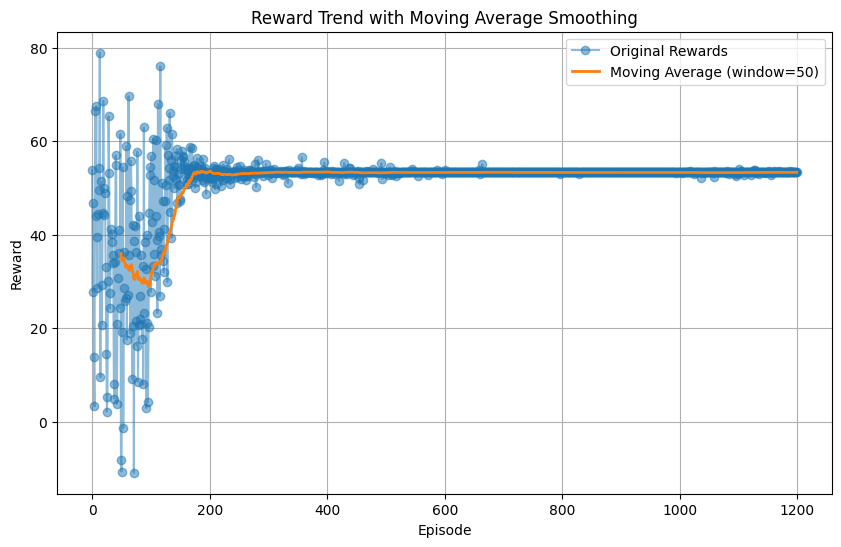

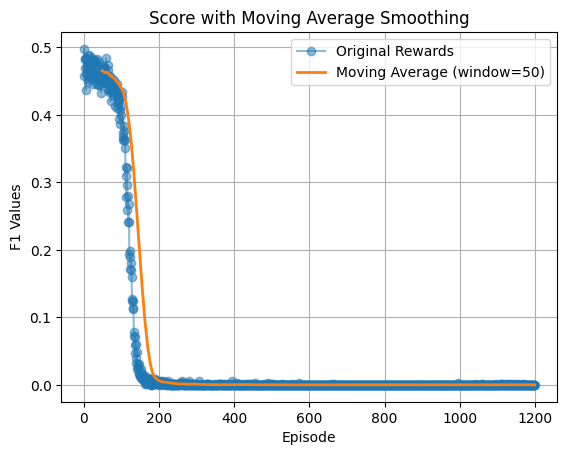

In [ ]:
episodes = epis 
rewards = rewards_list

# Moving average smoothing
window_size = 50
moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
score_avg = np.convolve(score_list, np.ones(window_size)/window_size, mode='valid')

# Plot
plt.figure(figsize=(10,6))
plt.plot(episodes, rewards, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], moving_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward Trend with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(episodes, score_list, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], score_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("F1 Values")
plt.title("Score with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
import contextlib

class GreedyAgent:
    def __init__(self, action):
        self.action = action
    def act(self, state):
        return self.action  # Always buy
    
def evaluate_agent(env, model, episodes=10):
    total_reward = 0
    f1_array = []
    is_torch_model = hasattr(model, 'eval')

    if is_torch_model:
        model.eval()
        context = torch.no_grad()
    else:
        context = contextlib.nullcontext()  # behaves like no `with` block

    with context:
        for _ in range(episodes):
            steps = 0
            action_array = []
            state = env.reset()
            done = False
            ep_reward = 0
            while not done:
                steps += 1
                
                action = model.act(state) if not is_torch_model else model.act(state)[0]
                action_array.append(action)
                
                state, reward, done, _ = env.step(action)
                ep_reward += reward
            total_reward += ep_reward
            f1_array.append(f1_score(y_true=y[:-2], y_pred=np.array(action_array)))

    avg_reward = total_reward / episodes
    print(f"Average reward over {episodes} episodes: {avg_reward} | Steps: {steps} | F1-Score: {np.mean(f1_array)}")
    return avg_reward, action_array

# For greedy baseline
re_train_env = env(data= df1.copy(), training=True)

print(1)
greedy_agent = GreedyAgent(action=1)
evaluate_agent(re_train_env, greedy_agent, episodes=10)

print(0)
greedy_agent = GreedyAgent(action=0)
evaluate_agent(re_train_env, greedy_agent, episodes=10)

# For your trained PPO agent
print()
ppo.model.load_state_dict(torch.load("ppo_trained.pth"))
evaluate_agent(re_train_env, ppo.model, episodes=10)
print()

NameError: name 'env' is not defined

### standard - parrallel No-regimes:

#### Data

In [69]:
feature_set = ['close', 'volume', 'return', 'log_return', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcw', 'volatility_dcp', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'others_dr']
df1, _ = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=True, feature_selection=feature_set)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

LogR: 0.6213595158808086


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/nei

RF: 0.45371227721326557
KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/

RF: 0.45371227721326557


In [70]:
l = []

for feature_name in df1.columns:
    if "prediction" in feature_name and "collab" not in feature_name:
        l.append(feature_name)
    #if "pred" in feature_name or "proba" in feature_name:
    if "final_pred" in feature_name or "proba" in feature_name:
        l.append(feature_name)
    '''
    if "regimes" == feature_name:
        l.append(feature_name)
    '''
     
df1 = df1.loc[:, ~df1.columns.isin(l)]
#df1['return'] = (df1['return'] - df1['return'].mean() ) / df1['return'].std()
#df1['return'] = df1['return'] / df1['return'].std()

display(df1.head())

,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,regimes,collab_prediction
0,7.82,-0.811073,0.00,-0.035769,1.149375,-1.452408,0.517340,-0.050688,-0.038947,0.082699,...,0.081218,0.886388,1.919126,1.954113,1.609774,1.752463,0.313919,0.315771,1,0.0
1,7.77,-0.523942,-0.07,-0.522450,1.140409,-1.456174,0.869181,-0.067306,0.103335,0.106168,...,0.086416,0.163493,2.070926,1.969968,1.427866,1.746246,-0.037194,-0.770908,0,0.0
2,7.77,-0.624223,-0.12,-0.867425,1.140409,-1.462168,0.845274,-0.075603,0.023961,0.100986,...,0.129950,-0.618722,2.339311,2.293814,1.899041,1.855028,0.719748,-0.194754,0,0.0
3,7.74,-0.687630,-0.10,-0.732370,1.130181,-1.456952,0.902658,-0.089013,-0.027570,0.077618,...,0.089393,-0.452167,2.321728,1.789657,1.890100,1.939894,0.562335,-1.812377,0,0.0
4,7.86,-0.591284,0.00,-0.035769,1.107686,-1.461676,0.654668,-0.070612,-0.002589,0.079595,...,-0.072364,-0.368087,2.276525,1.312614,1.749310,1.973797,0.226881,0.865139,1,0.0


#### Train

In [98]:
early_stop = False
episodes_completed = 0
while episodes_completed < max_episodes and not early_stop:
    episodes_completed += 1
    no_improve_count = patience
    if no_improve_count >= patience:
        print(episodes_completed)
        break

1


In [115]:
from collections import deque

import numpy as np
import torch
import random
from sklearn.metrics import f1_score
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor

# -----------------------------------
# PPO Training with Replay + Early Stop
# -----------------------------------

diagnostics = PPO_Diagnostics()
state_dim, action_dim = len(df1.columns), 2

ppo = PPO_LSTM_parrallel(state_dim, action_dim)
memory = Memory()

max_episodes = 500000

n_envs = 200
env_fns = [make_env(df1, seed=42, rank=i) for i in range(n_envs)]
vec_env = VecMonitor(DummyVecEnv(env_fns))  # or DummyVecEnv for debugging

# -----------------------------------
# PPO Training with Replay + Early Stop
# -----------------------------------

replay_buffer, best_experiences = [], []
seq_len=50
batch_size = 128

# Early stopping
episodes_completed, patience = 0, 1000
best_avg_reward, no_improve_count = -float("inf"), 0
rewards_history, score_list = [], []

# Obs + sequence buffers
obs = np.asarray(vec_env.reset())   # shape: (n_envs, state_dim)
seq_buffers = [deque(maxlen=seq_len) for _ in range(n_envs)]
for i in range(n_envs):
    for _ in range(seq_len):
        seq_buffers[i].append(np.zeros(state_dim, dtype=np.float32))  # warmup with zeros
    seq_buffers[i].append(obs[i])

episode_rewards = np.zeros(n_envs, dtype=np.float32)
episode_data = [[] for _ in range(n_envs)]
episode_preds = [[] for _ in range(n_envs)]
per_env_memory = [Memory() for _ in range(n_envs)]

hx = ppo.model.init_hidden(n_envs)

# -------------------------
# Main training loop
# -------------------------
early_stop = False
while episodes_completed < max_episodes and not early_stop:
    # Build state sequences
    state_seqs = np.array([list(seq_buffers[i]) for i in range(n_envs)])  # (n_envs, seq_len, state_dim)
    state_seqs_tensor = torch.tensor(state_seqs, dtype=torch.float32, device=device)

    # Get actions
    with torch.no_grad():
        actions_np, log_probs, values, new_hx = ppo.model.act(state_seqs_tensor, hx)
        if isinstance(actions_np, torch.Tensor):
            actions_np = actions_np.cpu().numpy()
        actions_np = np.asarray(actions_np).reshape(n_envs,)

    # Step envs
    next_obs, rewards, dones, infos = vec_env.step(actions_np)
    next_obs = np.asarray(next_obs)
    rewards = np.asarray(rewards).astype(np.float32)
    dones = np.asarray(dones).astype(bool)

    # Convert logprobs/values
    logp_np = log_probs.detach().cpu().numpy() if isinstance(log_probs, torch.Tensor) else np.asarray(log_probs)
    values_np = values.detach().cpu().numpy() if isinstance(values, torch.Tensor) else np.asarray(values)

    # Store transitions
    for i in range(n_envs):
        s = state_seqs[i]     # full seq
        a = int(actions_np[i])
        lp = float(logp_np[i])
        r = float(rewards[i])
        done = bool(dones[i])
        ns = next_obs[i]

        transition = (s, a, lp, r, done, ns)
        episode_data[i].append(transition)
        episode_preds[i].append(a)
        episode_rewards[i] += r

        per_env_memory[i].add(s, a, lp, r, done)
        seq_buffers[i].append(ns)

    # Reset hidden states for done envs
    h, c = new_hx
    done_indices = np.where(dones)[0]
    if len(done_indices) > 0:
        for idx in done_indices:
            h[:, idx, :].zero_()
            c[:, idx, :].zero_()
    obs = next_obs
    hx = (h, c)

    # Handle finished episodes
    for i in range(n_envs):
        if dones[i]:
            ep_reward = float(episode_rewards[i])
            ep_data, ep_preds, mem = episode_data[i], episode_preds[i], per_env_memory[i]

            replay_buffer.extend(ep_data)
            replay_buffer = replay_buffer[-5000:]

            # Best buffer
            if ep_reward > best_avg_reward:
                best_experiences.extend(ep_data)
                best_experiences = best_experiences[-2000:]

            # Update PPO
            mix_ratio = 0.4
            if len(replay_buffer) >= batch_size and len(best_experiences) >= int(mix_ratio * batch_size):
                recent_batch = random.sample(replay_buffer, int((1 - mix_ratio) * batch_size))
                best_batch = random.sample(best_experiences, int(mix_ratio * batch_size))
                batch = recent_batch + best_batch
                random.shuffle(batch)
                ppo.update_from_batch(batch)
            else:
                try:
                    ppo.update(mem)
                except:
                    ppo.update(vars(mem))

            # Reset trackers
            per_env_memory[i] = Memory()
            episode_data[i], episode_preds[i] = [], []
            episode_rewards[i] = 0.0

            # Logging
            rewards_history.append(ep_reward)
            episodes_completed += 1

            if len(rewards_history) >= 50:
                avg_reward = float(np.mean(rewards_history[-50:]))
                if avg_reward > best_avg_reward + 1e-3:
                    best_avg_reward, no_improve_count = avg_reward, 0
                else:
                    no_improve_count += 1

            # F1 logging
            try:
                score = f1_score(y[:len(ep_preds)], ep_preds)
            except:
                score = np.nan
            score_list.append(score)

            if episodes_completed % 100 == 0:
                print(f"[Episode {episodes_completed}] reward: {ep_reward:.3f} | avg50: {best_avg_reward:.3f} | F1: {score} | {np.unique(ep_preds, return_counts=True)}")
                torch.save(ppo.model.state_dict(), f"ppo_trained.pth")

    if no_improve_count >= patience:
        print(f"Early stopping after {episodes_completed} episodes.")
        vec_env.close()
        break

vec_env.close()
print("Training finished. Episodes completed:", episodes_completed)

[Episode 100] reward: 29.390 | avg50: 19.626 | F1: 0.4918032786885246 | (array([0, 1]), array([1227, 1342]))
[Episode 200] reward: 26.430 | avg50: 21.589 | F1: 0.5087025316455697 | (array([0, 1]), array([1200, 1369]))
[Episode 300] reward: 29.580 | avg50: 26.304 | F1: 0.5131729667812142 | (array([0, 1]), array([1109, 1460]))
[Episode 400] reward: 16.040 | avg50: 26.304 | F1: 0.4975162399694306 | (array([0, 1]), array([1111, 1458]))
[Episode 500] reward: 15.100 | avg50: 26.304 | F1: 0.49924242424242427 | (array([0, 1]), array([1088, 1481]))
[Episode 600] reward: 18.390 | avg50: 26.304 | F1: 0.5257186081694403 | (array([0, 1]), array([1084, 1485]))
[Episode 700] reward: 44.120 | avg50: 30.118 | F1: 0.5154483798040693 | (array([0, 1]), array([1074, 1495]))
[Episode 800] reward: 13.800 | avg50: 30.118 | F1: 0.5136363636363637 | (array([0, 1]), array([1088, 1481]))
[Episode 900] reward: 46.220 | avg50: 31.561 | F1: 0.5114877589453861 | (array([0, 1]), array([1073, 1496]))
[Episode 1000] rew

#### Plots

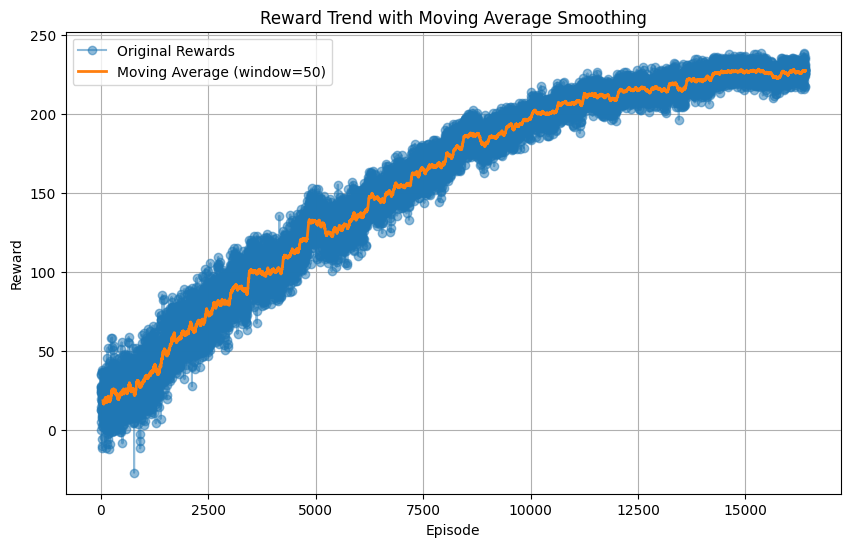

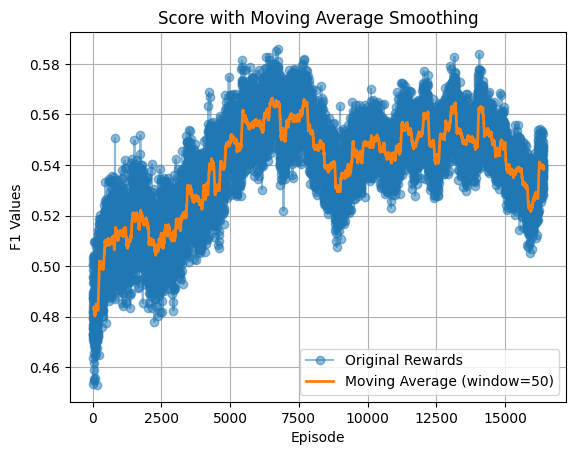

In [116]:
episodes = range(episodes_completed)
rewards = rewards_history

# Moving average smoothing
window_size = 50
moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
score_avg = np.convolve(score_list, np.ones(window_size)/window_size, mode='valid')

# Plot
plt.figure(figsize=(10,6))
plt.plot(episodes, rewards, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], moving_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward Trend with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(episodes, score_list, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], score_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("F1 Values")
plt.title("Score with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

### standard - parrallel:

In [62]:
feature_set = ['close', 'volume', 'return', 'log_return', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcw', 'volatility_dcp', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'others_dr']
df1, _ = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=True, feature_selection=feature_set)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

LogR: 0.6213595158808086
RF: 0.45371227721326557
KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

RF: 0.45371227721326557


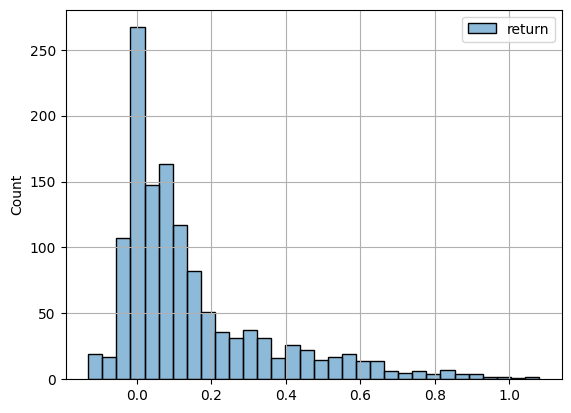

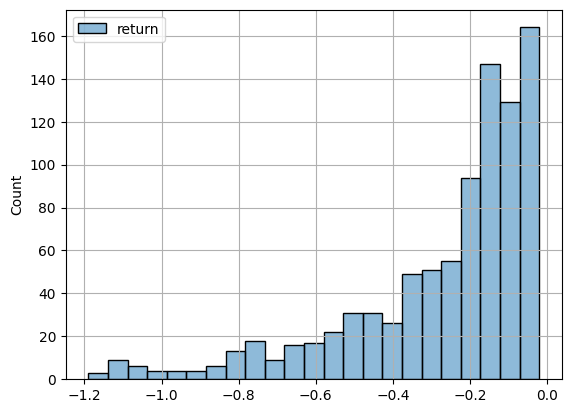

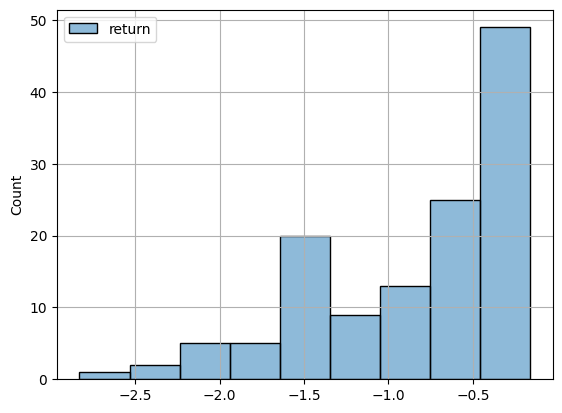

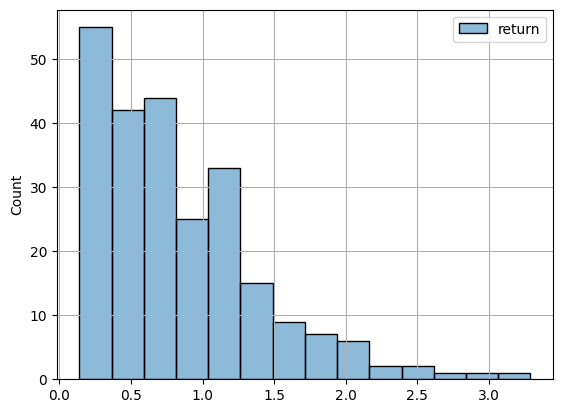

In [117]:
import seaborn as sns

for i in df1.regimes.unique():
    plt.grid(True)
    sns.histplot(df1.loc[ df1.regimes == i, ['return']])
    plt.show()

In [64]:
l = []

for feature_name in df1.columns:
    if "prediction" in feature_name and "collab" not in feature_name:
        l.append(feature_name)
    #if "pred" in feature_name or "proba" in feature_name:
    if "final_pred" in feature_name or "proba" in feature_name:
        l.append(feature_name)
    '''
    if "regimes" == feature_name:
        l.append(feature_name)
    '''
     
df1 = df1.loc[:, ~df1.columns.isin(l)]
#df1['return'] = (df1['return'] - df1['return'].mean() ) / df1['return'].std()
df1['return'] = df1['return'] / df1['return'].std()

display(df1.head())

,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,regimes,collab_prediction
0,7.82,-0.811073,0.000000,-0.035769,1.149375,-1.452408,0.517340,-0.050688,-0.038947,0.082699,...,0.081218,0.886388,1.919126,1.954113,1.609774,1.752463,0.313919,0.315771,1,0.0
1,7.77,-0.523942,-0.145635,-0.522450,1.140409,-1.456174,0.869181,-0.067306,0.103335,0.106168,...,0.086416,0.163493,2.070926,1.969968,1.427866,1.746246,-0.037194,-0.770908,0,0.0
2,7.77,-0.624223,-0.249660,-0.867425,1.140409,-1.462168,0.845274,-0.075603,0.023961,0.100986,...,0.129950,-0.618722,2.339311,2.293814,1.899041,1.855028,0.719748,-0.194754,0,0.0
3,7.74,-0.687630,-0.208050,-0.732370,1.130181,-1.456952,0.902658,-0.089013,-0.027570,0.077618,...,0.089393,-0.452167,2.321728,1.789657,1.890100,1.939894,0.562335,-1.812377,0,0.0
4,7.86,-0.591284,0.000000,-0.035769,1.107686,-1.461676,0.654668,-0.070612,-0.002589,0.079595,...,-0.072364,-0.368087,2.276525,1.312614,1.749310,1.973797,0.226881,0.865139,1,0.0


In [67]:
from collections import deque

# -----------------------------------
# PPO Training with Replay + Early Stop
# -----------------------------------

seq_len=60

for regime in df1.regimes.unique():
    print("Training regime:", regime)
    state_dim, action_dim = len(df1.columns), 2

    ppo = PPO_LSTM_parrallel(state_dim, action_dim)
    memory = Memory()

    max_episodes = 3000
    n_envs = 12
    env_fns = [make_env(df1.loc[df1['regimes'] == regime, :], seed=42, rank=i) for i in range(n_envs)]
    vec_env = VecMonitor(DummyVecEnv(env_fns))

    replay_buffer, best_experiences = [], []
    batch_size = 128

    # Early stopping
    episodes_completed, patience = 0, 1000
    best_avg_reward, no_improve_count = -float("inf"), 0
    rewards_history, score_list = [], []

    # Obs + sequence buffers
    obs = np.asarray(vec_env.reset())   # shape: (n_envs, state_dim)
    seq_buffers = [deque(maxlen=seq_len) for _ in range(n_envs)]
    for i in range(n_envs):
        for _ in range(seq_len):
            seq_buffers[i].append(np.zeros(state_dim, dtype=np.float32))  # warmup with zeros
        seq_buffers[i].append(obs[i])

    episode_rewards = np.zeros(n_envs, dtype=np.float32)
    episode_data = [[] for _ in range(n_envs)]
    episode_preds = [[] for _ in range(n_envs)]
    per_env_memory = [Memory() for _ in range(n_envs)]

    hx = ppo.model.init_hidden(n_envs)

    # -------------------------
    # Main training loop
    # -------------------------
    early_stop = False
    while episodes_completed < max_episodes and not early_stop:
        # Build state sequences
        state_seqs = np.array([list(seq_buffers[i]) for i in range(n_envs)])  # (n_envs, seq_len, state_dim)
        state_seqs_tensor = torch.tensor(state_seqs, dtype=torch.float32, device=device)

        # Get actions
        with torch.no_grad():
            actions_np, log_probs, values, new_hx = ppo.model.act(state_seqs_tensor, hx)
            if isinstance(actions_np, torch.Tensor):
                actions_np = actions_np.cpu().numpy()
            actions_np = np.asarray(actions_np).reshape(n_envs,)

        # Step envs
        next_obs, rewards, dones, infos = vec_env.step(actions_np)
        next_obs = np.asarray(next_obs)
        rewards = np.asarray(rewards).astype(np.float32)
        dones = np.asarray(dones).astype(bool)

        # Convert logprobs/values
        logp_np = log_probs.detach().cpu().numpy() if isinstance(log_probs, torch.Tensor) else np.asarray(log_probs)
        values_np = values.detach().cpu().numpy() if isinstance(values, torch.Tensor) else np.asarray(values)

        # Store transitions
        for i in range(n_envs):
            s = state_seqs[i]     # full seq
            a = int(actions_np[i])
            lp = float(logp_np[i])
            r = float(rewards[i])
            done = bool(dones[i])
            ns = next_obs[i]

            transition = (s, a, lp, r, done, ns)
            episode_data[i].append(transition)
            episode_preds[i].append(a)
            episode_rewards[i] += r

            per_env_memory[i].add(s, a, lp, r, done)
            seq_buffers[i].append(ns)

        # Reset hidden states for done envs
        h, c = new_hx
        done_indices = np.where(dones)[0]
        if len(done_indices) > 0:
            for idx in done_indices:
                h[:, idx, :].zero_()
                c[:, idx, :].zero_()
        obs = next_obs
        hx = (h, c)

        # Handle finished episodes
        for i in range(n_envs):
            if dones[i]:
                ep_reward = float(episode_rewards[i])
                ep_data, ep_preds, mem = episode_data[i], episode_preds[i], per_env_memory[i]

                replay_buffer.extend(ep_data)
                replay_buffer = replay_buffer[-5000:]

                # Best buffer
                if ep_reward > best_avg_reward:
                    best_experiences.extend(ep_data)
                    best_experiences = best_experiences[-2000:]

                # Update PPO
                mix_ratio = 0.4
                if len(replay_buffer) >= batch_size and len(best_experiences) >= int(mix_ratio * batch_size):
                    recent_batch = random.sample(replay_buffer, int((1 - mix_ratio) * batch_size))
                    best_batch = random.sample(best_experiences, int(mix_ratio * batch_size))
                    batch = recent_batch + best_batch
                    random.shuffle(batch)
                    ppo.update_from_batch(batch)
                else:
                    try:
                        ppo.update(mem)
                    except:
                        ppo.update(vars(mem))

                # Reset trackers
                per_env_memory[i] = Memory()
                episode_data[i], episode_preds[i] = [], []
                episode_rewards[i] = 0.0

                # Logging
                rewards_history.append(ep_reward)
                episodes_completed += 1

                if len(rewards_history) >= 50:
                    avg_reward = float(np.mean(rewards_history[-50:]))
                    if avg_reward > best_avg_reward + 1e-3:
                        best_avg_reward, no_improve_count = avg_reward, 0
                    else:
                        no_improve_count += 1

                # F1 logging
                try:
                    score = f1_score(y[:len(ep_preds)], ep_preds)
                except:
                    score = np.nan
                score_list.append(score)

                if episodes_completed % 100 == 0:
                    print(f"[Episode {episodes_completed}] reward: {ep_reward:.3f} | avg50: {best_avg_reward:.3f} | F1: {score} | {np.unique(ep_preds, return_counts=True)}")

                if no_improve_count >= patience:
                    print(f"Early stopping after {episodes_completed} episodes.")
                    torch.save(ppo.model.state_dict(), f"ppo_trained_{regime}.pth")
                    vec_env.close()
                    early_stop = True

    print("Training finished. Episodes completed:", episodes_completed)

Training regime: 1
[Episode 100] reward: 211.244 | avg50: 188.527 | F1: 0.5779987569919205 | (array([0, 1]), array([ 244, 1045]))
[Episode 200] reward: 227.295 | avg50: 224.239 | F1: 0.583579444772593 | (array([0, 1]), array([ 160, 1129]))
[Episode 300] reward: 231.025 | avg50: 231.146 | F1: 0.5955967555040557 | (array([0, 1]), array([ 127, 1162]))
[Episode 400] reward: 232.991 | avg50: 235.372 | F1: 0.598300283286119 | (array([0, 1]), array([  88, 1201]))
[Episode 500] reward: 236.763 | avg50: 235.372 | F1: 0.6028921023359288 | (array([0, 1]), array([  55, 1234]))
[Episode 600] reward: 236.171 | avg50: 237.279 | F1: 0.6012201885745979 | (array([0, 1]), array([  50, 1239]))
[Episode 700] reward: 232.937 | avg50: 237.279 | F1: 0.5913734392735528 | (array([0, 1]), array([  91, 1198]))
[Episode 800] reward: 234.571 | avg50: 237.279 | F1: 0.6019955654101996 | (array([0, 1]), array([  49, 1240]))
[Episode 900] reward: 237.155 | avg50: 237.530 | F1: 0.6056955093099672 | (array([0, 1]), array

KeyboardInterrupt: 

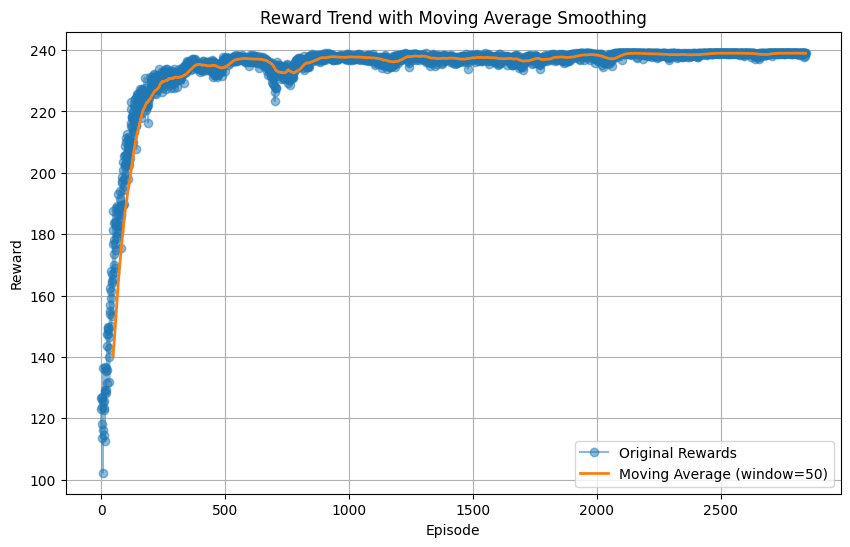

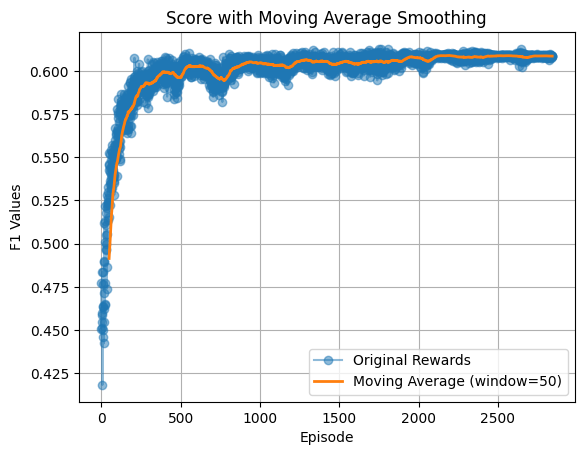

In [69]:
episodes = range(episodes_completed)
rewards = rewards_history

# Moving average smoothing
window_size = 50
moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
score_avg = np.convolve(score_list, np.ones(window_size)/window_size, mode='valid')

# Plot
plt.figure(figsize=(10,6))
plt.plot(episodes, rewards, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], moving_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward Trend with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(episodes, score_list, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], score_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("F1 Values")
plt.title("Score with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

### no LSTM

In [289]:
feature_set = ['close', 'volume', 'return', 'log_return', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcw', 'volatility_dcp', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'others_dr']
df1, _ = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=True, feature_selection=feature_set)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

LogR: 0.6213595158808086
RF: 0.45371227721326557
KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

RF: 0.45371227721326557


In [290]:
l = []

for feature_name in df1.columns:
    if "prediction" in feature_name and "collab" not in feature_name:
        l.append(feature_name)
    if "pred" in feature_name or "proba" in feature_name:
    #if "final_pred" in feature_name or "proba" in feature_name:
        l.append(feature_name)
    if "regimes" == feature_name:
        l.append(feature_name)
     
df1 = df1.loc[:, ~df1.columns.isin(l)]
#df1['return'] = (df1['return'] - df1['return'].mean() ) / df1['return'].mean()

display(df1.head())

,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_uo,momentum_stoch,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr
0,7.82,0.055676,0.00,0.479558,0.916565,0.002997,0.565843,0.529070,0.587993,0.568847,...,0.563386,0.581395,0.561223,0.624435,0.841838,0.789938,0.603522,0.758203,0.344207,0.507597
1,7.77,0.088622,-0.07,0.426093,0.914333,0.001841,0.621112,0.527885,0.595394,0.570691,...,0.543580,0.595238,0.562666,0.544502,0.861970,0.792046,0.576853,0.757150,0.303130,0.371417
2,7.77,0.077115,-0.12,0.388195,0.914333,0.000000,0.617356,0.527294,0.591265,0.570284,...,0.464533,0.547619,0.574751,0.458010,0.897564,0.835104,0.645930,0.775567,0.391684,0.443620
3,7.74,0.069840,-0.10,0.403032,0.911788,0.001602,0.626370,0.526338,0.588585,0.568448,...,0.323891,0.547619,0.563492,0.476426,0.895232,0.768072,0.644619,0.789934,0.373269,0.240903
4,7.86,0.080895,0.00,0.479558,0.906190,0.000151,0.587415,0.527650,0.589884,0.568603,...,0.354543,0.460526,0.518588,0.485723,0.889237,0.704645,0.623979,0.795674,0.334024,0.576442


In [291]:
import numpy as np
import torch
import random
from sklearn.metrics import f1_score
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor

# -----------------------------------
# PPO Training with Replay + Early Stop
# -----------------------------------

#diagnostics = PPO_Diagnostics()
state_dim, action_dim = len(df1.columns)-2, 2

ppo = PPO_FF_parallel(state_dim, action_dim)
memory = Memory()

max_episodes = 5000

n_envs = 12
env_fns = [make_env(df1, seed=42, rank=i) for i in range(n_envs)]
vec_env = VecMonitor(DummyVecEnv(env_fns))  # or DummyVecEnv for debugging

In [313]:
import numpy as np
import torch
import random
from sklearn.metrics import f1_score
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

# Buffers
replay_buffer = []
best_experiences = []
batch_size = 128

# Early stopping
max_episodes = 5000
episodes_completed = 0
patience = 1000
best_avg_reward = -float("inf")
no_improve_count = 0

# Tracking
rewards_history = []
score_list = []
rewards_list = []

# Reset envs
obs = vec_env.reset()
obs = np.asarray(obs)
episode_rewards = np.zeros(n_envs, dtype=np.float32)
episode_data = [[] for _ in range(n_envs)]
episode_preds = [[] for _ in range(n_envs)]
per_env_memory = [Memory() for _ in range(n_envs)]

# Init hidden states
try:
    hx = ppo.model.init_hidden(n_envs)
except Exception:
    lstm_hidden = 64
    hx = (torch.zeros(1, n_envs, lstm_hidden, device=device),
          torch.zeros(1, n_envs, lstm_hidden, device=device))

# === TRAINING LOOP ===
while episodes_completed < max_episodes:
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device)

    # Actions from PPO
    with torch.no_grad():
        actions, log_probs, values, new_hx = ppo.model.act(obs_tensor, hx)
        if isinstance(actions, torch.Tensor):
            actions = actions.cpu().numpy()
        actions = np.asarray(actions).reshape(n_envs,)

    # Step parallel envs
    next_obs, rewards, dones, infos = vec_env.step(actions)
    next_obs = np.asarray(next_obs)
    rewards = np.asarray(rewards, dtype=np.float32)
    dones = np.asarray(dones, dtype=bool)

    rewards_list.append(rewards)

    # Convert outputs
    logp_np = log_probs.detach().cpu().numpy() if isinstance(log_probs, torch.Tensor) else np.asarray(log_probs)
    values_np = values.detach().cpu().numpy() if isinstance(values, torch.Tensor) else np.asarray(values)

    # Store transitions
    for i in range(n_envs):
        s = obs[i]
        a = int(actions[i])
        lp = float(logp_np[i])
        r = float(rewards[i])
        d = bool(dones[i])
        ns = next_obs[i]

        transition = (s, a, lp, r, d, ns)
        episode_data[i].append(transition)
        episode_preds[i].append(a)
        episode_rewards[i] += r

        try:
            per_env_memory[i].add(s, a, lp, r, d)
        except:
            per_env_memory[i].add(s, a, lp, r, d)

    # Reset hidden states for done envs
    if new_hx is not None:
        h, c = new_hx          # works only for recurrent models
        done_indices = np.where(dones)[0]
        for idx in done_indices:
            h[:, idx, :].zero_()
            c[:, idx, :].zero_()
        hx = (h, c)
    else:
        # Feedforward agent: just drop hidden state
        hx = None
    obs = next_obs

    # Handle finished episodes
    for i in range(n_envs):
        if dones[i]:
            ep_reward = float(episode_rewards[i])
            ep_data = episode_data[i]
            ep_preds = episode_preds[i]
            mem = per_env_memory[i]

            # Replay buffer management
            replay_buffer.extend(ep_data)
            replay_buffer = replay_buffer[-5000:]

            # Best experiences
            if ep_reward > best_avg_reward:
                best_experiences.extend(ep_data)
                best_experiences = best_experiences[-2000:]

            # Train PPO
            mix_ratio = 0.4
            if len(replay_buffer) >= batch_size and len(best_experiences) >= int(mix_ratio * batch_size):
                recent_batch = random.sample(replay_buffer, int((1 - mix_ratio) * batch_size))
                best_batch = random.sample(best_experiences, int(mix_ratio * batch_size))
                batch = recent_batch + best_batch
                random.shuffle(batch)
                entropy_bonus, advantages, critic_loss, rewards_, ratios = ppo.update_from_batch(batch)
            else:
                try:
                    entropy_bonus, advantages, critic_loss, rewards_, ratios = ppo.update(mem)
                except:
                    entropy_bonus, advantages, critic_loss, rewards_, ratios = ppo.update(vars(mem))

            # Reset episode trackers
            per_env_memory[i] = Memory()
            episode_data[i] = []
            episode_preds[i] = []
            episode_rewards[i] = 0.0

            # Logging
            rewards_history.append(ep_reward)
            episodes_completed += 1

            if len(rewards_history) >= 50:
                avg_reward = float(np.mean(rewards_history[-50:]))
                if avg_reward > best_avg_reward + 1e-3:
                    best_avg_reward = avg_reward
                    no_improve_count = 0
                else:
                    no_improve_count += 1

            try:
                score = f1_score(y[:len(ep_preds)], ep_preds)
            except:
                score = np.nan
            score_list.append(score)

            torch.save(ppo.model.state_dict(), f"ppo_trained.pth")

            if episodes_completed % 100 == 0:
                print(f"[Episode {episodes_completed}] reward: {ep_reward:.3f} | recent_avg: {best_avg_reward:.3f} | F1: {score} | {np.unique(ep_preds, return_counts=True)}")

            if no_improve_count >= patience:
                print(f"Early stopping: no improvement for {patience} episodes. Stopping after {episodes_completed} episodes.")
                break

    if no_improve_count >= patience:
        break

vec_env.close()
print("Training finished. Episodes completed:", episodes_completed)

[Episode 100] reward: -19.650 | recent_avg: -19.651 | F1: 0.0 | (array([0]), array([2569]))
[Episode 200] reward: -19.650 | recent_avg: -19.631 | F1: 0.0 | (array([0]), array([2569]))
[Episode 300] reward: -19.650 | recent_avg: -19.631 | F1: 0.0 | (array([0]), array([2569]))


KeyboardInterrupt: 

### RND

In [163]:
df1, _ = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=False)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4792988573070674


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

LogR: 0.6251979258799023


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_18555/2108625444.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['final_preds'] = voting_method(data=df1.copy())
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ra

RF: 0.5338744683532318
KNNs: 0.4792988573070674


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used 

LogR: 0.6251979258799023
RF: 0.5338744683532318


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_18555/2108625444.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['final_preds'] = voting_method(data=df2.copy())
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_18555/2108625444.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[j] = scale_1[j]
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_18555/2108625444.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [164]:
display(df1.head())

,close,return,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,final_preds,regimes
0,14.25,0.00,1.0,1,-1.010518,1,0.399242,1,1,2
1,14.28,0.03,1.0,1,-0.984671,1,0.236310,1,1,2
2,14.28,0.06,0.0,0,-1.158154,1,-0.198310,1,0,2
3,14.22,-0.12,0.0,0,-1.090912,1,0.344291,1,0,2
4,14.22,0.00,0.0,0,-1.199147,1,0.399242,1,0,2


In [166]:
state_dim, action_dim = len(df1.columns)-2, 2

train_env = TradingEnv(data= df1.copy(), )
ppo = PPO_LSTM_RND(state_dim, action_dim)
memory = Memory()

#episodes, rewards = train_ppo(train_env, ppo, memory, max_episodes=2000)

# -----------------------------------
# Training function Recording:
# -----------------------------------
import random

max_episodes = 5000
env = train_env

epis = []
rewards = []
rewards_history = []

# Early stopping parameters
patience = 1000
best_avg_reward = -float("inf")
no_improve_count = 0

# Replay buffers
replay_buffer = []
best_experiences = []
batch_size = 128  # adjust to your PPO minibatch size

for episode in range(max_episodes):
    state = env.reset()
    ep_reward = 0
    done = False
    hx = None  # LSTM hidden state
    memory.clear()
    step = 0
    episode_data = []  # store current episode transitions
    y_pred = []

    while not done:
        step += 1
        action, logprob, value, hx = ppo.model.act(state, hx)
        next_state, reward, done, _ = env.step(action)

        transition = (state, action, logprob.item(), reward, done, next_state)
        memory.add(*transition[:-1])  # original PPO memory
        episode_data.append(transition)  # store for replay buffer

        state = next_state
        ep_reward += reward
        y_pred.append(action)
        
    # Save the last state in memory
    memory.next_state = next_state

    # --- Replay Mix Training ---
    # Add current episode to main replay buffer
    replay_buffer.extend(episode_data)
    # Keep replay buffer bounded to avoid excessive memory
    replay_buffer = replay_buffer[-5000:]  # keep last N steps

    # If this episode is among the best, add to best_experiences
    if ep_reward > best_avg_reward:
        best_experiences.extend(episode_data)
        # Keep best experiences fresh
        best_experiences = best_experiences[-2000:]

    # Create a mixed batch: 80% recent, 20% best
    size = 0.4
    if len(replay_buffer) >= batch_size and len(best_experiences) >= int(size * batch_size):
        recent_batch = random.sample(replay_buffer, int((1-size) * batch_size))
        best_batch = random.sample(best_experiences, int(size * batch_size))
        batch = recent_batch + best_batch
        random.shuffle(batch)

        # Pass mixed batch directly to your update_from_batch
        ppo.update_from_batch(batch)

    else:
        # Fall back to standard PPO update with current episode memory
        ppo.update(vars(memory))

    # Clear memory after update
    memory.clear()

    # Track episode reward history
    rewards_history.append(ep_reward)

    # --- Early stopping logic ---
    if len(rewards_history) >= 50:
        last_50 = rewards_history[-50:]
        avg_reward = np.mean([
            r.cpu().detach().numpy() if isinstance(r, torch.Tensor) else r
            for r in last_50
        ])

        if avg_reward > best_avg_reward + 1e-3:
            best_avg_reward = avg_reward
            no_improve_count = 0
        else:
            no_improve_count += 1
    
    '''
    if no_improve_count >= patience:
        print(f"Early stopping at episode {episode}")
        break
    '''

    # Log progress
    epis.append(episode)
    rewards.append(ep_reward)
    if episode % 50 == 0:
        print(f"Episode {episode} | step: {step} | reward: {ep_reward:.2f} | F1-Score: {f1_score(y[:-2], y_pred):.2f} | Precision: {precision_score(y[:-2], y_pred):.2f}")
#---------------------------------------------------------------------------------------------------------------------------------------

### save the trained model
torch.save(ppo.model.state_dict(), "ppo_trained.pth")

Episode 0 | step: 1891 | reward: 4.60 | F1-Score: 0.42 | Precision: 0.52
Episode 50 | step: 1891 | reward: -6.93 | F1-Score: 0.36 | Precision: 0.44
Episode 100 | step: 1891 | reward: -11.96 | F1-Score: 0.37 | Precision: 0.43
Episode 150 | step: 1891 | reward: -2.22 | F1-Score: 0.40 | Precision: 0.48
Episode 200 | step: 1891 | reward: -1.78 | F1-Score: 0.39 | Precision: 0.45
Episode 250 | step: 1891 | reward: -7.50 | F1-Score: 0.36 | Precision: 0.42
Episode 300 | step: 1891 | reward: -6.00 | F1-Score: 0.38 | Precision: 0.44
Episode 350 | step: 1891 | reward: -54.54 | F1-Score: 0.41 | Precision: 0.46
Episode 400 | step: 1891 | reward: -15.55 | F1-Score: 0.37 | Precision: 0.42
Episode 450 | step: 1891 | reward: -2.49 | F1-Score: 0.40 | Precision: 0.45
Episode 500 | step: 1891 | reward: -16.58 | F1-Score: 0.40 | Precision: 0.44
Episode 550 | step: 1891 | reward: 21.51 | F1-Score: 0.43 | Precision: 0.48
Episode 600 | step: 1891 | reward: -7.74 | F1-Score: 0.42 | Precision: 0.45
Episode 650 

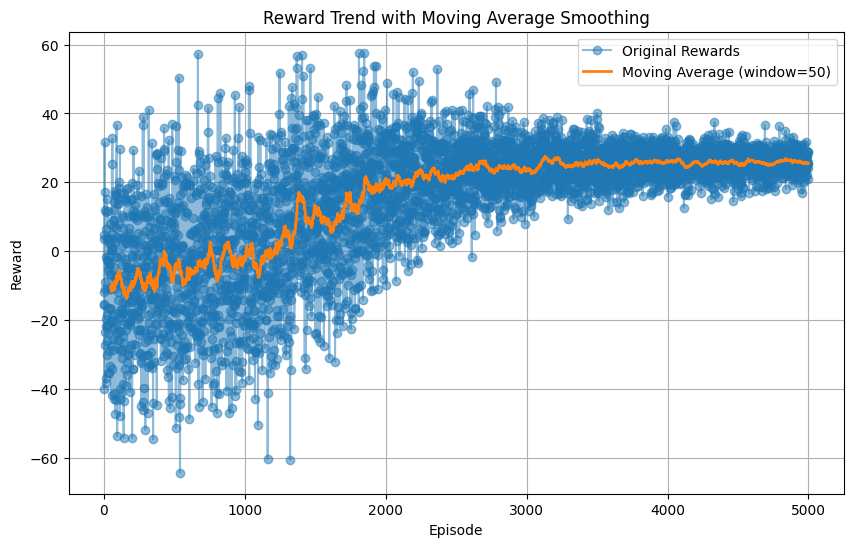

In [167]:
episodes = epis

# Moving average smoothing
window_size = 50
moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

# Plot
plt.figure(figsize=(10,6))
plt.plot(episodes, rewards, label="Original Rewards", alpha=0.5, marker='o')
plt.plot(episodes[window_size-1:], moving_avg, label=f"Moving Average (window={window_size})", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward Trend with Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

# Hyper-params Tuning:

In [49]:
import optuna
import torch
import numpy as np

hyper_tuning ={}

for regime in df1.regimes.unique():
    
    print(f"REGIME NO. {regime}")
    state_dim, action_dim = len(df1.columns), 2

    memory = Memory()

    n_envs = 12
    env_fns = [make_env(df1.loc[ df1['regimes'] == regime, :], seed=42, rank=i) for i in range(n_envs)]
    vec_env = VecMonitor(DummyVecEnv(env_fns))  # or DummyVecEnv for debugging
    
    replay_buffer = []
    best_experiences = []

    def objective(trial):
        # --- Suggest hyperparameters ---
        lr = trial.suggest_loguniform("lr", 1e-5, 3e-4)
        gamma = trial.suggest_uniform("gamma", 0.90, 0.99)
        lambd = trial.suggest_uniform("lambd", 0.90, 0.97)
        eps_clip = trial.suggest_uniform("eps_clip", 0.1, 0.3)
        K_epochs = trial.suggest_int("K_epochs", 3, 8)
        entropy_coef = trial.suggest_loguniform("entropy_coef", 1e-3, 5e-2)
        vf_coef = trial.suggest_uniform("vf_coef", 0.25, 1.0)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512, 1024])
        #mix_ratio = trial.suggest_uniform("mix_ratio", 0.2, 0.6)
        max_grad_norm = trial.suggest_uniform("gradient_clip", 0.3, 1.0)

        # --- Init PPO model with trial params ---
        ppo = PPO_LSTM_parrallel(
            state_dim, action_dim,
            lr=lr, gamma=gamma, lambd=lambd,
            eps_clip=eps_clip, K_epochs=K_epochs,
            entropy_coef=entropy_coef, vf_coef=vf_coef,
            gradient_clip=max_grad_norm, batch_size=batch_size
        )

        # --- Reset env ---
        obs = vec_env.reset()
        obs = np.asarray(obs)
        hx = ppo.model.init_hidden(n_envs)  # init hidden LSTM states

        # trackers
        rewards_history = []
        episodes_completed = 0
        max_episodes = 500  # shorten for tuning
        patience = 100
        no_improve_count = 0
        best_avg_reward = -float("inf")

        # --- Training loop ---
        while episodes_completed < max_episodes:
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
            with torch.no_grad():
                actions_np, log_probs, values, new_hx = ppo.model.act(obs_tensor, hx)
            actions_np = np.asarray(actions_np).reshape(n_envs,)

            next_obs, rewards, dones, infos = vec_env.step(actions_np)
            next_obs = np.asarray(next_obs)
            rewards = np.asarray(rewards).astype(np.float32)
            dones = np.asarray(dones).astype(bool)

            # Update hidden state
            hx = new_hx

            # Track rewards per env
            for i in range(n_envs):
                if dones[i]:
                    ep_reward = float(rewards[i])
                    rewards_history.append(ep_reward)
                    episodes_completed += 1

                    # Early stop condition
                    if len(rewards_history) >= 20:
                        avg_reward = np.mean(rewards_history[-20:])
                        if avg_reward > best_avg_reward + 1e-3:
                            best_avg_reward = avg_reward
                            no_improve_count = 0
                        else:
                            no_improve_count += 1
                    if no_improve_count >= patience:
                        break

            obs = next_obs
            if no_improve_count >= patience:
                break

        # --- Objective metric (maximize) ---
        final_score = np.mean(rewards_history[-20:]) if rewards_history else -1e9
        return final_score

    # === Run Study ===
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)

    print("Best hyperparameters:", study.best_params)
    print("Best reward:", study.best_value)

    hyper_tuning[f"Regime {regime}"] = {
        "Params" : study.best_params,
        "Reward" : study.best_value
    }

[I 2025-09-19 10:45:20,675] A new study created in memory with name: no-name-605921cd-6e69-45b6-8d96-da9ed036d902


REGIME NO. 1


[I 2025-09-19 10:57:24,051] Trial 0 finished with value: -0.003999999910593033 and parameters: {'lr': 2.9714388009008397e-05, 'gamma': 0.9530170801605622, 'lambd': 0.9547726966158308, 'eps_clip': 0.25227942806076475, 'K_epochs': 7, 'entropy_coef': 0.009875667431515212, 'vf_coef': 0.7709682162655288, 'batch_size': 1024, 'gradient_clip': 0.5633599837631744}. Best is trial 0 with value: -0.003999999910593033.
[I 2025-09-19 10:59:29,712] Trial 1 finished with value: -0.0054999998770654205 and parameters: {'lr': 7.61272079141963e-05, 'gamma': 0.9215953021149013, 'lambd': 0.9266655014983619, 'eps_clip': 0.27104151319709524, 'K_epochs': 8, 'entropy_coef': 0.0026480017289282477, 'vf_coef': 0.3893734905910618, 'batch_size': 256, 'gradient_clip': 0.5700713290604156}. Best is trial 0 with value: -0.003999999910593033.
[I 2025-09-19 11:03:15,787] Trial 2 finished with value: -0.0054999998770654205 and parameters: {'lr': 0.00018373064819467323, 'gamma': 0.9182119337687565, 'lambd': 0.95133472392595

Best hyperparameters: {'lr': 0.0002977174795194939, 'gamma': 0.9877649765647496, 'lambd': 0.9014209556528388, 'eps_clip': 0.10445918249588482, 'K_epochs': 8, 'entropy_coef': 0.0011467676958226162, 'vf_coef': 0.5964870621799074, 'batch_size': 512, 'gradient_clip': 0.9586866313740874}
Best reward: -0.0019999999552965165
REGIME NO. 0


[I 2025-09-19 12:19:45,333] Trial 0 finished with value: -0.004499999899417162 and parameters: {'lr': 2.216088002679277e-05, 'gamma': 0.9645775245796347, 'lambd': 0.9215334262429838, 'eps_clip': 0.25544777056024415, 'K_epochs': 4, 'entropy_coef': 0.008222593341316933, 'vf_coef': 0.6821814799002617, 'batch_size': 512, 'gradient_clip': 0.5556186539522672}. Best is trial 0 with value: -0.004499999899417162.
[I 2025-09-19 12:22:57,161] Trial 1 finished with value: -0.0054999998770654205 and parameters: {'lr': 0.0002765134551742911, 'gamma': 0.9191949700577139, 'lambd': 0.9176415303740227, 'eps_clip': 0.22099530141062418, 'K_epochs': 6, 'entropy_coef': 0.005990987029305392, 'vf_coef': 0.6026190516098204, 'batch_size': 1024, 'gradient_clip': 0.8676191203988435}. Best is trial 0 with value: -0.004499999899417162.
[I 2025-09-19 12:23:30,706] Trial 2 finished with value: -0.0054999998770654205 and parameters: {'lr': 1.2162109618552326e-05, 'gamma': 0.9806028476828309, 'lambd': 0.958587137051623

Best hyperparameters: {'lr': 0.00017632992727929022, 'gamma': 0.9335897452242349, 'lambd': 0.9424870110090386, 'eps_clip': 0.16652352129545178, 'K_epochs': 3, 'entropy_coef': 0.017428794578329916, 'vf_coef': 0.716539121531196, 'batch_size': 128, 'gradient_clip': 0.4974514946442816}
Best reward: -0.0024999999441206455
REGIME NO. 3


[I 2025-09-19 13:10:15,121] Trial 0 finished with value: -0.0054999998770654205 and parameters: {'lr': 0.00010011734387872284, 'gamma': 0.96568696911645, 'lambd': 0.9447333571955662, 'eps_clip': 0.10792891598893611, 'K_epochs': 7, 'entropy_coef': 0.020392621263027086, 'vf_coef': 0.41249716981100404, 'batch_size': 256, 'gradient_clip': 0.7066512845577319}. Best is trial 0 with value: -0.0054999998770654205.
[I 2025-09-19 13:10:18,942] Trial 1 finished with value: -0.0029999999329447745 and parameters: {'lr': 0.0001258002203088684, 'gamma': 0.9289846625196295, 'lambd': 0.9276342584334272, 'eps_clip': 0.24845832382391123, 'K_epochs': 8, 'entropy_coef': 0.005408507898117249, 'vf_coef': 0.27611615145920776, 'batch_size': 128, 'gradient_clip': 0.7559342875037302}. Best is trial 1 with value: -0.0029999999329447745.
[I 2025-09-19 13:10:26,386] Trial 2 finished with value: -0.004499999899417162 and parameters: {'lr': 2.270152736981796e-05, 'gamma': 0.9510905146805213, 'lambd': 0.90997246351790

Best hyperparameters: {'lr': 8.057329800537838e-05, 'gamma': 0.9452743808645201, 'lambd': 0.9696101865567672, 'eps_clip': 0.28192816291477574, 'K_epochs': 7, 'entropy_coef': 0.008963897847232234, 'vf_coef': 0.3391327064376412, 'batch_size': 1024, 'gradient_clip': 0.989149949107499}
Best reward: -0.0014999999664723873
REGIME NO. 2


[I 2025-09-19 13:17:30,489] Trial 0 finished with value: 1.6976908206939698 and parameters: {'lr': 9.46319857566044e-05, 'gamma': 0.9729092595392111, 'lambd': 0.935201396116315, 'eps_clip': 0.22675464179021826, 'K_epochs': 7, 'entropy_coef': 0.0010977724620920284, 'vf_coef': 0.5550103314081711, 'batch_size': 256, 'gradient_clip': 0.8285123836395645}. Best is trial 0 with value: 1.6976908206939698.
[I 2025-09-19 13:18:16,123] Trial 1 finished with value: 0.9903196454048157 and parameters: {'lr': 2.7943336552346477e-05, 'gamma': 0.9744608532154752, 'lambd': 0.9542526556813479, 'eps_clip': 0.169675529067651, 'K_epochs': 7, 'entropy_coef': 0.03640973158551239, 'vf_coef': 0.2527863413817231, 'batch_size': 512, 'gradient_clip': 0.5216061987067588}. Best is trial 0 with value: 1.6976908206939698.
[I 2025-09-19 13:18:32,204] Trial 2 finished with value: 1.2732681155204773 and parameters: {'lr': 3.234072217679271e-05, 'gamma': 0.9372795952726722, 'lambd': 0.9419740455448312, 'eps_clip': 0.16855

Best hyperparameters: {'lr': 2.3746993149246794e-05, 'gamma': 0.9725675624579893, 'lambd': 0.9205527717452282, 'eps_clip': 0.22366849301908193, 'K_epochs': 4, 'entropy_coef': 0.029289380552429547, 'vf_coef': 0.5340568045520906, 'batch_size': 1024, 'gradient_clip': 0.870421943470947}
Best reward: 2.263587760925293


### Saving:

In [51]:
import joblib

package = hyper_tuning
joblib.dump(package, f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /RL model/PPO_best_params_separately.pkl")

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /RL model/PPO_best_params_separately.pkl']

# Testing:

In [42]:
from sklearn.metrics import f1_score, classification_report

def evaluate_ppo(env, ppo, episodes= 100, max_timesteps=12000):
    total_rewards = []
    actual_result = {"actual_movement": [], "actual_return": []}
    predictive_result = {"predictive_movement": [], "predictive_return": []}

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        actual_values = {"actual_movement": [], "actual_return": []}
        predictive_values = {"predictive_movement": [], "predictive_return": []}

        for _ in range(max_timesteps):
            with torch.no_grad():  # Disable gradient tracking
                action, _, _, _ = ppo.model.act(state)

            state, reward, done, actual = env.step(action)
            total_reward += reward
                
            # Values Record:
            actual_values['actual_movement'].append(actual['actual_movement'])
            actual_values['actual_return'].append(actual['Actual Return'])
            
            predictive_values["predictive_movement"].append(action)

            if done:
                break

        total_rewards.append(total_reward)

        # Values Record:
        for key in actual_result.keys():
            actual_result[key].append(actual_values[key])
        for key in predictive_result.keys():
            predictive_result[key].append(predictive_values[key])
        
        if ep % 10 == 0:
            print(f"Eval Episode {ep}\tReward: {total_reward:.2f}")

    avg_reward = sum(total_rewards) / len(total_rewards)
    print("\n" + f"Average Evaluation Predictive_Reward: {avg_reward:.2f}")
    #print(f"Average Evaluation True_Reward: {np.mean(np.array(actual_result['actual_return']).sum(axis=1))}")
    
    return_array = []
    for i in range(np.array(actual_result["actual_return"]).shape[0]):
        #return_array.append( np.sum(predictive_result['predictive_return'][i]) / np.sum(actual_result['actual_return'][i]) )
        return_array.append( total_rewards[i] / np.sum(actual_result['actual_return'][i]) )
    
    rate_of_return = np.mean(return_array)
    
    f1_array = []
    for i in range(np.array(actual_result["actual_movement"]).shape[0]):
        f1_array.append(f1_score(y_true=actual_result['actual_movement'][i], y_pred=predictive_result['predictive_movement'][i]))
    
    return (
        {
            "Mean Rate of Return": rate_of_return, 
            "Mean F1-Score": np.mean(f1_array),
        }, 
        classification_report(y_true= np.concatenate([i for i in actual_result["actual_movement"]]), y_pred= np.concatenate([i for i in predictive_result["predictive_movement"]]))
    )
    
import numpy as np
import torch
from sklearn.metrics import f1_score


def test_ppo_model(ppo, vec_env, n_episodes=50, device="cpu", y=None, label_mode: str = "step"):
    """
    Test PPO model in vectorized environments.

    Args:
        ppo: trained PPO object with .model.act()
        vec_env: vectorized environment (SubprocVecEnv / DummyVecEnv)
        n_episodes: number of episodes to test
        device: torch device
        y: ground truth labels (optional)
           - if label_mode="episode": len(y) must match n_episodes
           - if label_mode="step": len(y) must match number of steps taken
        label_mode: "episode" or "step" to decide how to evaluate predictions

    Returns:
        results dict with avg_reward, action_counts, f1_score
    """
    if label_mode not in ["episode", "step"]:
        raise ValueError(f"label_mode must be 'episode' or 'step', got {label_mode}")

    n_envs = vec_env.num_envs
    obs = vec_env.reset()
    obs = np.asarray(obs)

    # init hidden states
    try:
        hx = ppo.model.init_hidden(n_envs)
    except Exception:
        lstm_hidden = 64
        hx = (torch.zeros(1, n_envs, lstm_hidden, device=device),
              torch.zeros(1, n_envs, lstm_hidden, device=device))

    rewards_per_ep = []
    ep_rewards = np.zeros(n_envs, dtype=np.float32)
    preds_per_ep = [[] for _ in range(n_envs)]

    all_preds = []  # collected predictions
    episodes_done = 0

    while episodes_done < n_episodes:
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
        with torch.no_grad():
            actions, _, _, new_hx = ppo.model.act(obs_tensor, hx)

        if isinstance(actions, torch.Tensor):
            actions = actions.cpu().numpy()
        actions = np.asarray(actions).reshape(n_envs,)

        next_obs, rewards, dones, infos = vec_env.step(actions)
        next_obs = np.asarray(next_obs)
        rewards = np.asarray(rewards).astype(np.float32)
        dones = np.asarray(dones).astype(bool)

        # track rewards and actions
        ep_rewards += rewards
        for i in range(n_envs):
            preds_per_ep[i].append(int(actions[i]))

        # reset hidden states for finished envs
        h, c = new_hx
        for idx in np.where(dones)[0]:
            h[:, idx, :].zero_()
            c[:, idx, :].zero_()
        hx = (h, c)

        obs = next_obs

        # finalize finished episodes
        for i in range(n_envs):
            if dones[i]:
                rewards_per_ep.append(float(ep_rewards[i]))

                if label_mode == "step":
                    all_preds.extend(preds_per_ep[i])   # log all actions from episode
                else:  # episode mode
                    if preds_per_ep[i]:
                        all_preds.append(preds_per_ep[i][-1])  # only last action

                episodes_done += 1
                ep_rewards[i] = 0.0
                preds_per_ep[i] = []  # reset buffer

                if episodes_done >= n_episodes:
                    break

    vec_env.close()

    # compute summary stats
    avg_reward = float(np.mean(rewards_per_ep)) if rewards_per_ep else 0.0
    action_counts = np.unique(all_preds, return_counts=True)

    # compute F1 score if labels are provided
    f1 = None
    if y is not None and len(all_preds) > 0:
        try:
            if label_mode == "episode":
                y = y[:n_episodes]   # trim if longer
            else:
                y = y[:len(all_preds)]
            f1 = f1_score(y, all_preds)
        except Exception:
            f1 = None

    results = {
        "avg_reward": avg_reward,
        "action_counts": action_counts,
        "f1_score": f1,
        "episodes_done": episodes_done,
        "steps_logged": len(all_preds),
    }
    print(
        f"Test Results -> Avg Reward: {avg_reward:.3f} | "
        f"F1: {f1} | Actions: {action_counts} | "
        f"Episodes: {episodes_done} | Steps: {len(all_preds)}"
    )
    return results


## Pre-tuned Model:

### Data Preparation

In [63]:
feature_set = ['close', 'volume', 'return', 'log_return', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcw', 'volatility_dcp', 'volatility_ui', 'trend_macd', 'trend_macd_diff', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_diff', 'trend_stc', 'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_aroon_up', 'trend_aroon_down', 'trend_aroon_ind', 'trend_psar_up_indicator', 'trend_psar_down_indicator', 'momentum_rsi', 'momentum_stoch_rsi', 'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'others_dr']
df1, df2 = dataset_preparation(sub_training_data, sub_testing_data, extended_feature=True, feature_selection=feature_set)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWa

LogR: 0.6213595158808086


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

RF: 0.45371227721326557
KNNs: 0.4512464279130463


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

RF: 0.45371227721326557


In [64]:
l = []

for feature_name in df1.columns:
    if "prediction" in feature_name and "collab" not in feature_name:
        l.append(feature_name)
    #if "pred" in feature_name or "proba" in feature_name:
    if "final_pred" in feature_name or "proba" in feature_name:
        l.append(feature_name)
    '''
    if "regimes" == feature_name:
        l.append(feature_name)
    '''
     
df1 = df1.loc[:, ~df1.columns.isin(l)]
df2 = df2.loc[:, df1.columns]

#df1['return'] = (df1['return'] - df1['return'].mean() ) / df1['return'].std()

display(df1, df2)

,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,regimes,collab_prediction
0,7.82,-0.811073,0.00,-0.035769,1.149375,-1.452408,0.517340,-0.050688,-0.038947,0.082699,...,0.081218,0.886388,1.919126,1.954113,1.609774,1.752463,0.313919,0.315771,1,0.0
1,7.77,-0.523942,-0.07,-0.522450,1.140409,-1.456174,0.869181,-0.067306,0.103335,0.106168,...,0.086416,0.163493,2.070926,1.969968,1.427866,1.746246,-0.037194,-0.770908,0,0.0
2,7.77,-0.624223,-0.12,-0.867425,1.140409,-1.462168,0.845274,-0.075603,0.023961,0.100986,...,0.129950,-0.618722,2.339311,2.293814,1.899041,1.855028,0.719748,-0.194754,0,0.0
3,7.74,-0.687630,-0.10,-0.732370,1.130181,-1.456952,0.902658,-0.089013,-0.027570,0.077618,...,0.089393,-0.452167,2.321728,1.789657,1.890100,1.939894,0.562335,-1.812377,0,0.0
4,7.86,-0.591284,0.00,-0.035769,1.107686,-1.461676,0.654668,-0.070612,-0.002589,0.079595,...,-0.072364,-0.368087,2.276525,1.312614,1.749310,1.973797,0.226881,0.865139,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566,44.80,-0.025871,-0.62,-0.781602,0.683547,1.762018,-2.086752,-0.271958,-6.321794,3.646798,...,1.015743,0.227233,-0.135869,1.750542,0.086960,0.062850,0.069316,2.498254,0,0.0
2567,45.31,0.112117,-0.23,-0.310527,0.648071,1.771878,-2.512371,-1.072831,-5.284256,2.360007,...,0.317356,0.594583,-0.132323,1.411431,0.152798,0.086716,0.160825,2.045578,0,0.0
2568,45.71,0.189181,-0.90,-1.093819,0.616692,1.782808,-2.888753,-0.806295,-1.405707,1.760463,...,-0.361016,0.615724,-0.090000,1.243637,0.434278,0.173767,0.576712,0.717857,0,0.0
2569,45.31,0.518027,-1.64,-1.965167,0.573452,1.794337,-3.044150,-0.651127,-0.767808,1.883305,...,-0.655491,0.860970,0.010927,1.265809,0.407807,0.237017,0.420049,-0.679047,3,1.0


,close,volume,return,log_return,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,...,momentum_stoch_signal,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,regimes,collab_prediction
2571,46.89,-0.483496,-0.06,-0.056472,0.472438,-1.453309,-1.950362,-0.055892,-0.182794,1.445389,...,-0.468066,-0.259160,0.383926,1.991951,0.183410,0.116279,0.171879,-0.036458,1,1.0
2572,47.57,-0.398209,0.68,1.190340,0.481908,-1.430596,-1.670676,-0.005530,0.257766,1.750062,...,-0.357454,-0.553822,0.535912,1.971739,0.387692,0.194424,0.439014,-4.390517,1,1.0
2573,47.57,-0.381538,0.00,0.045233,0.497027,-1.401350,-1.671473,0.020334,0.471034,1.854865,...,-0.243965,-0.408765,0.636987,1.827167,0.562309,0.301289,0.608312,-1.425895,1,1.0
2574,49.22,-0.190138,0.63,1.069802,0.484342,-1.370828,-1.219141,-0.020811,0.832511,1.382581,...,-0.321436,-1.880338,0.712309,1.646556,1.125970,0.529941,1.326192,-1.452459,1,1.0
2575,49.44,-0.032343,0.62,1.048920,0.507699,-1.325646,-1.129437,-0.051416,-1.413048,0.360018,...,-0.579105,-1.965956,0.878501,1.731249,1.126704,0.713050,1.057731,0.252262,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,69.00,2.330975,-0.50,-0.529015,-2.957888,4.622380,-0.312581,0.760550,0.040527,-0.203958,...,0.325985,0.223076,0.871357,2.152231,2.693927,1.920903,2.210686,-0.887782,0,1.0
3210,68.60,4.415748,-0.60,-0.647367,-3.042171,4.384103,-0.481328,1.323409,-0.004391,-0.144095,...,0.389753,-0.283794,1.193600,2.529372,2.907120,2.278014,2.083401,-0.036458,0,1.0
3211,67.00,4.246328,-1.80,-2.063278,-3.222185,3.986151,-0.685906,0.694971,0.278465,-0.108788,...,0.577305,1.501359,1.393738,2.523118,2.438041,2.444565,0.960132,1.070829,0,1.0
3212,68.90,2.381426,1.40,1.677934,-3.421207,3.601175,-0.399380,6.383122,-0.414806,-0.226422,...,0.576054,1.185610,1.424784,2.091647,2.025487,2.473024,0.146143,0.448420,1,1.0


### without regimes:

#### training:

In [ ]:
state_dim, action_dim = len(df1.columns), 2

memory = Memory()

n_envs = 100
env_fns = [make_env(df1, seed=42, rank=i) for i in range(n_envs)]
vec_env = VecMonitor(DummyVecEnv(env_fns))  # or DummyVecEnv for debugging

replay_buffer = []
best_experiences = []
batch_size = 128

# --- Init PPO model with trial params ---
ppo = PPO_LSTM_parrallel(state_dim, action_dim)

checkpoint_path = "ppo_trained copy.pth"
ppo.model.load_state_dict(torch.load(checkpoint_path, map_location=device))
'''
ppo.model.train() # set to evaluation mode if you don't want dropout/batchnorm randomness
# Train / continue training
train_ppo_parrallel(vec_env, n_envs, ppo, memory, max_episodes=1000)
'''

"\nppo.model.train() # set to evaluation mode if you don't want dropout/batchnorm randomness\n# Train / continue training\ntrain_ppo_parrallel(vec_env, n_envs, ppo, memory, max_episodes=1000)\n"

#### validation:

<Axes: title={'center': 'df1'}, xlabel='return', ylabel='Count'>

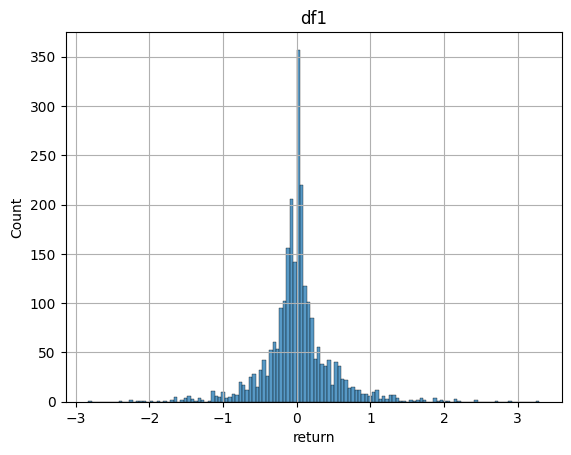

In [90]:
import seaborn as sns

plt.grid(True)
plt.title("df1")
sns.histplot(df1["return"])

In [ ]:
import torch
import numpy as np
from sklearn.metrics import f1_score

# --- Load trained PPO model ---
ppo.model.eval()

# --- Validation environment(s) ---
n_eval_envs = 50 # fewer than training
val_env_fns = [make_env(df1, seed=42, rank=i) for i in range(n_eval_envs)]
val_env = VecMonitor(DummyVecEnv(val_env_fns))
test_ppo_model(ppo, val_env, y=y[1:-1].copy(), label_mode="step", n_episodes=10)

Test Results -> Avg Reward: 228.167 | F1: None | Actions: (array([0, 1]), array([15090, 10600])) | Episodes: 10 | Steps: 25690


{'avg_reward': 228.1669921875,
 'action_counts': (array([0, 1]), array([15090, 10600])),
 'f1_score': None,
 'episodes_done': 10,
 'steps_logged': 25690}

<Axes: title={'center': 'df2'}, xlabel='return', ylabel='Count'>

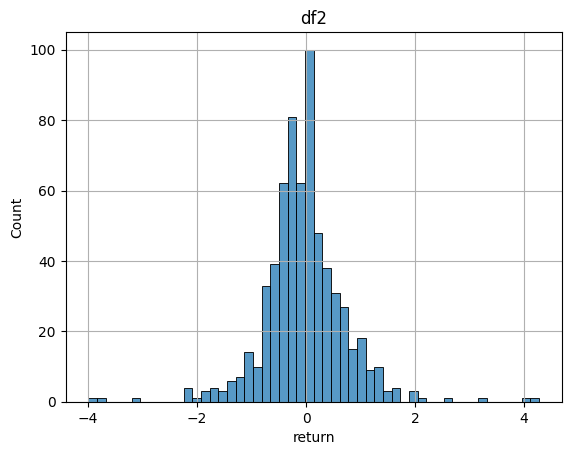

In [89]:
import seaborn as sns

plt.grid(True)
plt.title("df2")
sns.histplot(df2["return"])

In [83]:
# --- Load trained PPO model ---
ppo.model.eval()

# --- Validation environment(s) ---
n_eval_envs = 50 # fewer than training
val_env_fns = [make_env(df2, seed=42, rank=i) for i in range(n_eval_envs)]
val_env = VecMonitor(DummyVecEnv(val_env_fns))
test_ppo_model(ppo, val_env, y=Valid_result[1:-1].copy(), label_mode="step", n_episodes=10)

Test Results -> Avg Reward: -7.056 | F1: None | Actions: (array([0, 1]), array([5117, 1293])) | Episodes: 10 | Steps: 6410


{'avg_reward': -7.056000781059265,
 'action_counts': (array([0, 1]), array([5117, 1293])),
 'f1_score': None,
 'episodes_done': 10,
 'steps_logged': 6410}

### with regimes:

#### training:

In [ ]:
hyper_tuning = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /RL model/PPO_best_params_separately.pkl")

for regime in df1.regimes.unique():
    
    print(f"REGIME NO. {regime}")
    state_dim, action_dim = len(df1.columns), 2

    memory = Memory()

    n_envs = 12
    env_fns = [make_env(df1.loc[ df1['regimes'] == regime, :], seed=42, rank=i) for i in range(n_envs)]
    vec_env = VecMonitor(DummyVecEnv(env_fns))  # or DummyVecEnv for debugging
    
    replay_buffer = []
    best_experiences = []
    batch_size = 128

    # --- Init PPO model with trial params ---
    ppo = PPO_LSTM_parrallel(
        state_dim, action_dim,
        **hyper_tuning[f"Regime {regime}"]["Params"]
    )

    train_ppo_parrallel(vec_env, n_envs, ppo, memory, max_episodes=1000)
    
    torch.save(ppo.model.state_dict(), f"ppo_trained {regime}.pth")

REGIME NO. 1
[Episode 100] reward: 239.003 | recent_avg: 228.014 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 200] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 300] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 400] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 500] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 600] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 700] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 800] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 900] reward: 239.003 | recent_avg: 239.003 | F1: 0.6087425796006476 | (array([1]), array([1289]))
[Episode 1000] reward: 2

#### validation:

In [69]:
for regime in df2.regimes.unique():
    
    print(f"REGIME NO. {regime}")
    state_dim, action_dim = len(df2.columns), 2

    memory = Memory()

    n_envs = 12
    env_fns = [make_env(df2.loc[ df2['regimes'] == regime, :], seed=42, rank=i) for i in range(n_envs)]
    vec_env = VecMonitor(DummyVecEnv(env_fns))  # or DummyVecEnv for debugging
    
    replay_buffer = []
    best_experiences = []
    batch_size = 128

    # --- Init PPO model with trial params ---
    ppo = PPO_LSTM_parrallel(
        state_dim, action_dim,
        **hyper_tuning[f"Regime {regime}"]["Params"]
    )
    ppo.model.load_state_dict(torch.load(f"ppo_trained {regime}.pth"))
    
    test_ppo_model(ppo, vec_env)

REGIME NO. 1
Test Results -> Avg Reward: 141.362 | F1: None | Actions: (array([1]), array([3861]))
REGIME NO. 0
Test Results -> Avg Reward: 0.000 | F1: None | Actions: (array([0]), array([2838]))
REGIME NO. 2
Test Results -> Avg Reward: 8.508 | F1: None | Actions: (array([1]), array([165]))
REGIME NO. 3
Test Results -> Avg Reward: 0.000 | F1: None | Actions: (array([0]), array([121]))
